<a href="https://colab.research.google.com/github/clee2026/MSDS_498/blob/main/capstone/finding_large/notebook_4_clustering_operational_segmentation_report_ready_v5_with_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: NYC 311 Clustering and Operational Segmentation, Report Ready Version

This notebook adds an optional clustering and operational segmentation layer to the existing NYC 311 capstone workflow. It does **not** replace the supervised learning models from Notebook 3.

**Recommended input:** the Notebook 2 output file named `analysis_ready_sample.parquet`.

**Upload one file into the Colab `/content` directory:**

1. `analysis_ready_sample.parquet`, or  
2. `notebook2_output_files.zip` or `notebook2_outputs.zip` containing `analysis_ready_sample.parquet`

This notebook saves every chart, table, manifest, and report-ready output into one folder named `notebook4_clustering_outputs`, then creates a downloadable ZIP file at the end.

## Step 0: Purpose and how this connects to Notebooks 1 to 3

Notebooks 1 to 3 already provide EDA, feature engineering, regression modeling, classification modeling, feature importance, and KPI evaluation. Those supervised models answer predictive questions such as which complaints are associated with longer response times or lower same-day closure likelihood.

This notebook answers a different set of questions:

- Which geographic areas behave like recurring complaint hotspots?
- Which complaint records form similar operational segments?
- Which segments show longer response times, lower same-day closure rates, or stronger repeat complaint behavior?
- Which groups are most relevant for management review, staffing, inspections, or long-term resource planning?

The main improvement in this version is that cluster IDs are translated into **operational segment names** and **management interpretation tables**.

The notebook converts coordinates to numeric values, fills invalid geographic masks as `False`, and safely creates geographic cells before clustering.


## Step 1: Upload the input file

In Colab, upload **one** of the following files into the `/content` directory:

- `analysis_ready_sample.parquet`
- `notebook2_output_files.zip`
- `notebook2_outputs.zip`

The notebook automatically searches for the parquet file directly. If it is not found, it searches for a Notebook 2 ZIP and extracts the parquet from it.

In [ ]:
# Step 1: Imports and output directory setup

import os
import json
import zipfile
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

OUTPUT_DIR = Path("/content/notebook4_clustering_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
DATA_DIR = OUTPUT_DIR / "data"
REPORT_DIR = OUTPUT_DIR / "report_ready"

for folder in [OUTPUT_DIR, TABLE_DIR, PLOT_DIR, DATA_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output directory ready: {OUTPUT_DIR}")

Output directory ready: /content/notebook4_clustering_outputs


In [ ]:
# Step 2: Locate or extract the Notebook 2 analysis-ready parquet file

SEARCH_ROOTS = [Path("/content"), Path("/content/drive/MyDrive"), Path(".")]
EXPECTED_PARQUET_NAME = "analysis_ready_sample.parquet"
EXPECTED_ZIP_NAMES = ["notebook2_output_files.zip", "notebook2_outputs.zip"]


def find_file(filename, roots):
    for root in roots:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
    return None

parquet_path = find_file(EXPECTED_PARQUET_NAME, SEARCH_ROOTS)

if parquet_path is None:
    zip_path = None
    for zname in EXPECTED_ZIP_NAMES:
        zip_path = find_file(zname, SEARCH_ROOTS)
        if zip_path is not None:
            break

    if zip_path is not None:
        extract_dir = Path("/content/notebook2_extracted_for_notebook4")
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        parquet_path = find_file(EXPECTED_PARQUET_NAME, [extract_dir])
        print(f"Extracted Notebook 2 ZIP: {zip_path}")
    else:
        raise FileNotFoundError(
            "Could not find analysis_ready_sample.parquet, notebook2_output_files.zip, or notebook2_outputs.zip. "
            "Upload one of those files to /content and rerun this cell."
        )

print(f"Using input parquet: {parquet_path}")

Extracted Notebook 2 ZIP: /content/notebook2_output_files.zip
Using input parquet: /content/notebook2_extracted_for_notebook4/notebook2_ouput_files/analysis_ready_sample.parquet


## Step 3: Load and validate the analysis-ready dataset

This step confirms that the clustering input includes the fields needed for operational segmentation. The core requirement is complaint type, borough, agency, and response time. Geographic clustering also requires latitude and longitude.

In [ ]:
# Step 3: Load data and validate key fields

df = pd.read_parquet(parquet_path)
print(f"Loaded shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

required_core = ["complaint_type", "borough", "agency", "response_time_hours"]
required_geo = ["latitude", "longitude"]
required_time = ["created_date", "closed_date"]
optional_flags = ["closed_same_day_flag", "repeat_complaint_flag"]

all_expected = required_core + required_geo + required_time + optional_flags
validation_rows = []
for col in all_expected:
    validation_rows.append({
        "column": col,
        "present": col in df.columns,
        "missing_rate": float(df[col].isna().mean()) if col in df.columns else np.nan,
        "dtype": str(df[col].dtype) if col in df.columns else "MISSING"
    })

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(TABLE_DIR / "data_quality_for_clustering.csv", index=False)
display(validation_df)

missing_core = [c for c in required_core if c not in df.columns]
if missing_core:
    raise ValueError(f"Missing required core fields: {missing_core}")

Loaded shape: 150,000 rows x 39 columns


,descriptor_2,landmark,intersection_street_1,intersection_street_2,cross_street_2,cross_street_1,address_type,location_type,city,street_name,resolution_description,descriptor,council_district,source_file,source_parquet,borough,community_board,park_borough,park_facility_name,agency,agency_name,complaint_type,open_data_channel_type,police_precinct,status,bbl,incident_address,closed_date,latitude,longitude,x_coordinate_state_plane,y_coordinate_state_plane,incident_zip,resolution_action_updated_date,created_date,unique_key,response_time_hours,closed_same_day_flag,repeat_complaint_flag
0,UNKNOWN,DE REIMER AVENUE,EDENWALD AVENUE,BUSSING AVENUE,BUSSING AVENUE,EDENWALD AVENUE,ADDRESS,Residential Building/House,BRONX,DEREIMER AVENUE,The New York City Police Department responded ...,Loud Music/Party,12.0,nyc_311_all_appended.parquet,batch_0.parquet,BRONX,12 BRONX,BRONX,Unspecified,NYPD,New York City Police Department,Noise - Residential,ONLINE,Precinct 47,Closed,2050210040.0,4172 DEREIMER AVENUE,2026-04-03 20:38:28,40.89477399367178,-73.84341190767061,1027542.0,265307.0,10466.0,2026-04-03 20:38:32,2026-04-03 15:05:33,68557295,5.548611,1,1
1,Street,132 STREET,VAN SICLEN STREET,131 STREET,131 STREET,VAN SICLEN STREET,ADDRESS,Street,SOUTH RICHMOND HILL,132 STREET,The Department of Sanitation found an open ser...,Cone,28.0,nyc_311_all_appended.parquet,batch_0.parquet,QUEENS,10 QUEENS,QUEENS,Unspecified,DSNY,Department of Sanitation,Obstruction,ONLINE,Precinct 106,Closed,4095920074.0,105-19 132 STREET,2026-03-30 10:27:34,40.688709519199314,-73.81337953995205,1036005.0,190247.0,11419.0,2026-03-30 10:27:37,2026-03-30 09:17:48,68502105,1.162778,1,1
2,BROKEN OR MISSING,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,ADDRESS,RESIDENTIAL BUILDING,NEW YORK,WEST 204 STREET,The following complaint conditions are still o...,DOOR,10.0,nyc_311_all_appended.parquet,batch_100000.parquet,MANHATTAN,12 MANHATTAN,MANHATTAN,Unspecified,HPD,Department of Housing Preservation and Develop...,DOOR/WINDOW,PHONE,Precinct 34,Open,1022210017.0,590 WEST 204 STREET,NaT,40.86483772421322,-73.92172676858291,1005900.0,254371.0,10034.0,2026-03-24 00:00:00,2026-03-24 09:59:46,68445209,NaN,0,1
3,UNKNOWN,GRIMSBY STREET,GREELEY AVENUE,DEAD END,DEAD END,GREELEY AVENUE,ADDRESS,Street,STATEN ISLAND,GRIMSBY STREET,Your report was submitted and will be used to ...,Snow Tracking,50.0,nyc_311_all_appended.parquet,batch_1000000.parquet,STATEN ISLAND,02 STATEN ISLAND,STATEN ISLAND,Unspecified,DSNY,Department of Sanitation,Snow or Ice,MOBILE,Precinct 122,Closed,5038850056.0,393 GRIMSBY STREET,2025-12-27 08:35:03,40.57054386925422,-74.09739427872815,957192.0,147156.0,10306.0,2025-12-27 08:35:06,2025-12-27 08:11:04,67313553,0.399722,1,1
4,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,EDENWALD AVENUE,STRANG AVENUE,ADDRESS,Street,BRONX,GRACE AVENUE,The owner claimed the vehicle.Â Your request i...,Derelict Vehicles,12.0,nyc_311_all_appended.parquet,batch_100000.parquet,BRONX,12 BRONX,BRONX,Unspecified,DSNY,Department of Sanitation,Derelict Vehicles,PHONE,Precinct 47,Closed,2049790050.0,4087 GRACE AVENUE,2026-03-19 04:45:00,40.89186702025594,-73.84518740343698,1027053.0,264247.0,10466.0,2026-03-19 12:00:00,2026-03-18 17:58:00,68379487,10.783333,0,1


,column,present,missing_rate,dtype
0,complaint_type,True,0.00000,string
1,borough,True,0.00000,string
2,agency,True,0.00000,string
3,response_time_hours,True,0.14922,float64
4,latitude,True,0.00000,string
5,longitude,True,0.00000,string
6,created_date,True,0.00000,datetime64[ns]
7,closed_date,True,0.14922,datetime64[ns]
8,closed_same_day_flag,True,0.00000,int64
9,repeat_complaint_flag,True,0.00000,int64


## Step 4: Prepare clustering features

This step cleans the core fields, converts coordinates to numeric values, creates time variables, and builds a stronger repeat complaint proxy. The proxy does not identify the same resident. It identifies recurring complaint behavior by combining complaint type, geographic cell, and month.

In [ ]:
# Step 4: Basic cleaning and derived fields for clustering

work = df.copy()

# Parse dates.
for date_col in ["created_date", "closed_date"]:
    if date_col in work.columns:
        work[date_col] = pd.to_datetime(work[date_col], errors="coerce")

# Parse coordinates.
for coord_col in ["latitude", "longitude"]:
    if coord_col in work.columns:
        work[coord_col] = pd.to_numeric(work[coord_col], errors="coerce")

# Clean required text fields.
for col in ["complaint_type", "borough", "agency"]:
    work[col] = work[col].fillna("UNKNOWN").astype(str).str.strip().replace({"": "UNKNOWN"})

# Clean response time.
work["response_time_hours"] = pd.to_numeric(work["response_time_hours"], errors="coerce")
work = work[work["response_time_hours"].notna()].copy()
work = work[work["response_time_hours"] >= 0].copy()

# Cap extreme response times only for clustering features. Keep original response_time_hours for reporting.
upper_cap = work["response_time_hours"].quantile(0.99)
work["response_time_hours_capped"] = work["response_time_hours"].clip(upper=upper_cap)
work["log_response_time_hours"] = np.log1p(work["response_time_hours_capped"])

# Date features.
if "created_date" in work.columns:
    work["created_hour"] = work["created_date"].dt.hour.fillna(-1).astype(int)
    work["created_dayofweek"] = work["created_date"].dt.dayofweek.fillna(-1).astype(int)
    work["created_month"] = work["created_date"].dt.month.fillna(-1).astype(int)
    work["created_year_month"] = work["created_date"].dt.to_period("M").astype(str)
else:
    work["created_hour"] = -1
    work["created_dayofweek"] = -1
    work["created_month"] = -1
    work["created_year_month"] = "UNKNOWN"

# Existing flags, when available.
if "closed_same_day_flag" not in work.columns:
    work["closed_same_day_flag"] = np.nan
else:
    work["closed_same_day_flag"] = pd.to_numeric(work["closed_same_day_flag"], errors="coerce")

if "repeat_complaint_flag" not in work.columns:
    work["repeat_complaint_flag"] = np.nan
else:
    work["repeat_complaint_flag"] = pd.to_numeric(work["repeat_complaint_flag"], errors="coerce")

# Build a stronger repeat complaint proxy using complaint type + approximate geographic cell + month.
# Rounding to 3 decimals is roughly a neighborhood-block scale and is stable enough for an operational proxy.
if {"latitude", "longitude"}.issubset(work.columns):
    # Some parquet reads preserve pandas nullable values. Build a plain bool mask so np.where does not see pd.NA.
    lat_num = pd.to_numeric(work["latitude"], errors="coerce")
    lon_num = pd.to_numeric(work["longitude"], errors="coerce")
    valid_geo_proxy = (
        lat_num.between(40.45, 41.00, inclusive="both")
        & lon_num.between(-74.30, -73.65, inclusive="both")
    ).fillna(False).astype(bool).to_numpy()

    work["geo_cell_lat"] = np.where(valid_geo_proxy, lat_num.round(3).to_numpy(dtype="float64"), np.nan)
    work["geo_cell_lon"] = np.where(valid_geo_proxy, lon_num.round(3).to_numpy(dtype="float64"), np.nan)

    proxy_group_cols = ["complaint_type", "geo_cell_lat", "geo_cell_lon", "created_year_month"]
    work["complaint_geo_month_count"] = work.groupby(proxy_group_cols, dropna=False)["complaint_type"].transform("size")
    work["repeat_complaint_proxy"] = (work["complaint_geo_month_count"] >= 3).fillna(False).astype(int)
else:
    work["geo_cell_lat"] = np.nan
    work["geo_cell_lon"] = np.nan
    work["complaint_geo_month_count"] = np.nan
    work["repeat_complaint_proxy"] = work["repeat_complaint_flag"].fillna(0).astype(int)

# If an existing repeat flag is available, preserve it and combine it with the new proxy for a conservative signal.
if work["repeat_complaint_flag"].notna().any():
    work["repeat_complaint_proxy_combined"] = ((work["repeat_complaint_proxy"].fillna(0) == 1) | (work["repeat_complaint_flag"].fillna(0) == 1)).astype(int)
else:
    work["repeat_complaint_proxy_combined"] = work["repeat_complaint_proxy"].fillna(0).astype(int)

prep_preview_cols = [
    "complaint_type", "borough", "agency", "response_time_hours", "closed_same_day_flag",
    "repeat_complaint_proxy_combined", "complaint_geo_month_count", "created_year_month"
]
prep_preview_cols = [c for c in prep_preview_cols if c in work.columns]

print(f"Prepared clustering data shape: {work.shape}")
display(work[prep_preview_cols].head())

Prepared clustering data shape: (127611, 50)


,complaint_type,borough,agency,response_time_hours,closed_same_day_flag,repeat_complaint_proxy_combined,complaint_geo_month_count,created_year_month
0,Noise - Residential,BRONX,NYPD,5.548611,1,1,2,2026-04
1,Obstruction,QUEENS,DSNY,1.162778,1,1,5,2026-03
3,Snow or Ice,STATEN ISLAND,DSNY,0.399722,1,1,1,2025-12
4,Derelict Vehicles,BRONX,DSNY,10.783333,0,1,1,2026-03
5,Drinking,BROOKLYN,NYPD,0.155556,0,1,1,2026-03


## Step 5: Geographic hotspot clustering using DBSCAN

DBSCAN is used for geographic clustering because the number of hotspot areas does not need to be known in advance. This method is useful for NYC 311 because complaint hotspots can be irregularly shaped and concentrated in dense areas.

Each geographic cluster is summarized by volume, top complaint type, leading borough, average response time, and repeat complaint proxy rate.

In [ ]:
# Step 5: Geographic DBSCAN clustering

geo = work.copy()
geo["latitude"] = pd.to_numeric(geo.get("latitude"), errors="coerce")
geo["longitude"] = pd.to_numeric(geo.get("longitude"), errors="coerce")
geo = geo.dropna(subset=["latitude", "longitude"]).copy()
geo = geo[geo["latitude"].between(40.45, 41.00) & geo["longitude"].between(-74.30, -73.65)].copy()

print(f"Rows with valid NYC coordinates available for geographic clustering: {len(geo):,}")

MAX_GEO_ROWS = 25000
if len(geo) > MAX_GEO_ROWS:
    geo_sample = geo.sample(MAX_GEO_ROWS, random_state=42).copy()
else:
    geo_sample = geo.copy()

# Default cluster value in case DBSCAN cannot run in the runtime.
geo_sample["geo_cluster_id"] = -1
geo_sample["geo_cluster_method"] = "not_run"

try:
    coords = geo_sample[["latitude", "longitude"]].astype("float64").to_numpy()
    coords_rad = np.radians(coords)
    earth_radius_miles = 3958.8
    eps_miles = 0.25
    eps_rad = eps_miles / earth_radius_miles
    min_samples = 25

    db = DBSCAN(
        eps=eps_rad,
        min_samples=min_samples,
        metric="haversine",
        algorithm="ball_tree"
    )
    geo_sample["geo_cluster_id"] = db.fit_predict(coords_rad)
    geo_sample["geo_cluster_method"] = "dbscan_haversine"
    n_clusters = int(len(set(geo_sample["geo_cluster_id"]) - {-1}))
    print(f"DBSCAN geographic clusters found, excluding noise: {n_clusters:,}")
except Exception as e:
    print("DBSCAN could not complete in this runtime. Falling back to grid-based hotspot cells.")
    print(f"Reason: {e}")
    geo_sample["geo_grid_cell"] = geo_sample["latitude"].round(3).astype(str) + "," + geo_sample["longitude"].round(3).astype(str)
    top_cells = geo_sample["geo_grid_cell"].value_counts()
    cell_to_id = {cell: idx for idx, cell in enumerate(top_cells.index)}
    geo_sample["geo_cluster_id"] = geo_sample["geo_grid_cell"].map(cell_to_id).fillna(-1).astype(int)
    geo_sample["geo_cluster_method"] = "grid_fallback"
    n_clusters = int(geo_sample["geo_cluster_id"].nunique())

# Summarize non-noise geographic hotspots.
geo_clustered = geo_sample[geo_sample["geo_cluster_id"] != -1].copy()
if len(geo_clustered) == 0:
    print("No non-noise geographic clusters were found. The notebook will continue with operational clustering.")
    geo_summary = pd.DataFrame()
else:
    geo_summary = (
        geo_clustered
        .groupby("geo_cluster_id")
        .agg(
            complaint_count=("complaint_type", "size"),
            avg_response_time_hours=("response_time_hours", "mean"),
            median_response_time_hours=("response_time_hours", "median"),
            same_day_closure_rate=("closed_same_day_flag", "mean"),
            repeat_proxy_rate=("repeat_complaint_proxy_combined", "mean"),
            top_complaint_type=("complaint_type", lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN"),
            top_borough=("borough", lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN"),
            top_agency=("agency", lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN"),
            center_latitude=("latitude", "mean"),
            center_longitude=("longitude", "mean")
        )
        .reset_index()
        .sort_values("complaint_count", ascending=False)
    )

    geo_summary["geo_hotspot_rank"] = range(1, len(geo_summary) + 1)
    geo_summary["geo_hotspot_label"] = geo_summary.apply(
        lambda r: f"Hotspot {int(r['geo_hotspot_rank'])}: {r['top_borough']} | {r['top_complaint_type']}", axis=1
    )
    geo_summary["management_meaning"] = geo_summary.apply(
        lambda r: (
            "High-volume recurring service demand area" if r["repeat_proxy_rate"] >= geo_summary["repeat_proxy_rate"].median()
            else "High-volume geographic complaint concentration"
        ), axis=1
    )
    geo_summary.to_csv(TABLE_DIR / "geo_cluster_summary_report_ready.csv", index=False)
    geo_summary.to_csv(TABLE_DIR / "geo_cluster_summary.csv", index=False)
    display(geo_summary.head(15))

# Merge labels back to the geographic sample.
if len(geo_summary) > 0:
    geo_label_map = geo_summary.set_index("geo_cluster_id")["geo_hotspot_label"].to_dict()
    geo_sample["geo_hotspot_label"] = geo_sample["geo_cluster_id"].map(geo_label_map).fillna("Noise or Low Density Area")
else:
    geo_sample["geo_hotspot_label"] = "No Geographic Cluster Found"

Rows with valid NYC coordinates available for geographic clustering: 123,444
DBSCAN geographic clusters found, excluding noise: 39


,geo_cluster_id,complaint_count,avg_response_time_hours,median_response_time_hours,same_day_closure_rate,repeat_proxy_rate,top_complaint_type,top_borough,top_agency,center_latitude,center_longitude,geo_hotspot_rank,geo_hotspot_label,management_meaning
1,1,9405,75.457596,9.666667,0.479001,0.999894,HEAT/HOT WATER,MANHATTAN,NYPD,40.81633,-73.928964,1,Hotspot 1: MANHATTAN | HEAT/HOT WATER,High-volume geographic complaint concentration
0,0,5399,66.179356,3.951389,0.540470,1.000000,Illegal Parking,BROOKLYN,NYPD,40.676092,-73.956953,2,Hotspot 2: BROOKLYN | Illegal Parking,High-volume recurring service demand area
3,3,1110,38.600141,3.149167,0.609009,1.000000,Illegal Parking,QUEENS,NYPD,40.743276,-73.876047,3,Hotspot 3: QUEENS | Illegal Parking,High-volume recurring service demand area
4,4,1069,39.599818,3.478611,0.593078,1.000000,Illegal Parking,BROOKLYN,NYPD,40.602127,-73.971907,4,Hotspot 4: BROOKLYN | Illegal Parking,High-volume recurring service demand area
6,6,695,55.264986,7.794722,0.513669,1.000000,Illegal Parking,BROOKLYN,NYPD,40.677921,-73.874931,5,Hotspot 5: BROOKLYN | Illegal Parking,High-volume recurring service demand area
2,2,494,48.395676,2.791944,0.655870,1.000000,Illegal Parking,QUEENS,NYPD,40.766676,-73.919416,6,Hotspot 6: QUEENS | Illegal Parking,High-volume recurring service demand area
18,18,408,34.516592,2.725694,0.656863,1.000000,Illegal Parking,QUEENS,NYPD,40.685966,-73.82627,7,Hotspot 7: QUEENS | Illegal Parking,High-volume recurring service demand area
5,5,283,26.948246,0.639722,0.823322,1.000000,Noise - Vehicle,QUEENS,NYPD,40.722589,-73.808604,8,Hotspot 8: QUEENS | Noise - Vehicle,High-volume recurring service demand area
9,9,214,65.024775,7.710139,0.467290,1.000000,HEAT/HOT WATER,QUEENS,NYPD,40.705593,-73.801439,9,Hotspot 9: QUEENS | HEAT/HOT WATER,High-volume recurring service demand area
15,15,205,50.017992,3.586667,0.556098,1.000000,Noise - Residential,QUEENS,NYPD,40.758359,-73.826104,10,Hotspot 10: QUEENS | Noise - Residential,High-volume recurring service demand area


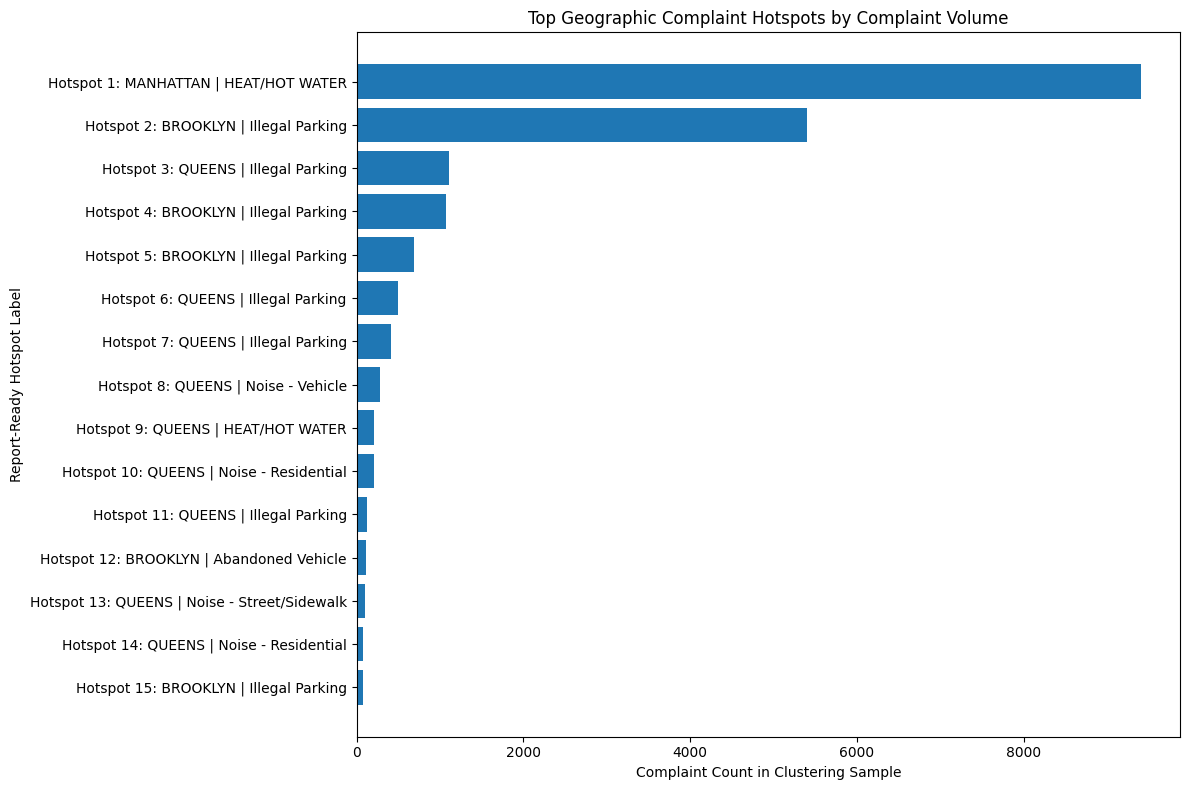

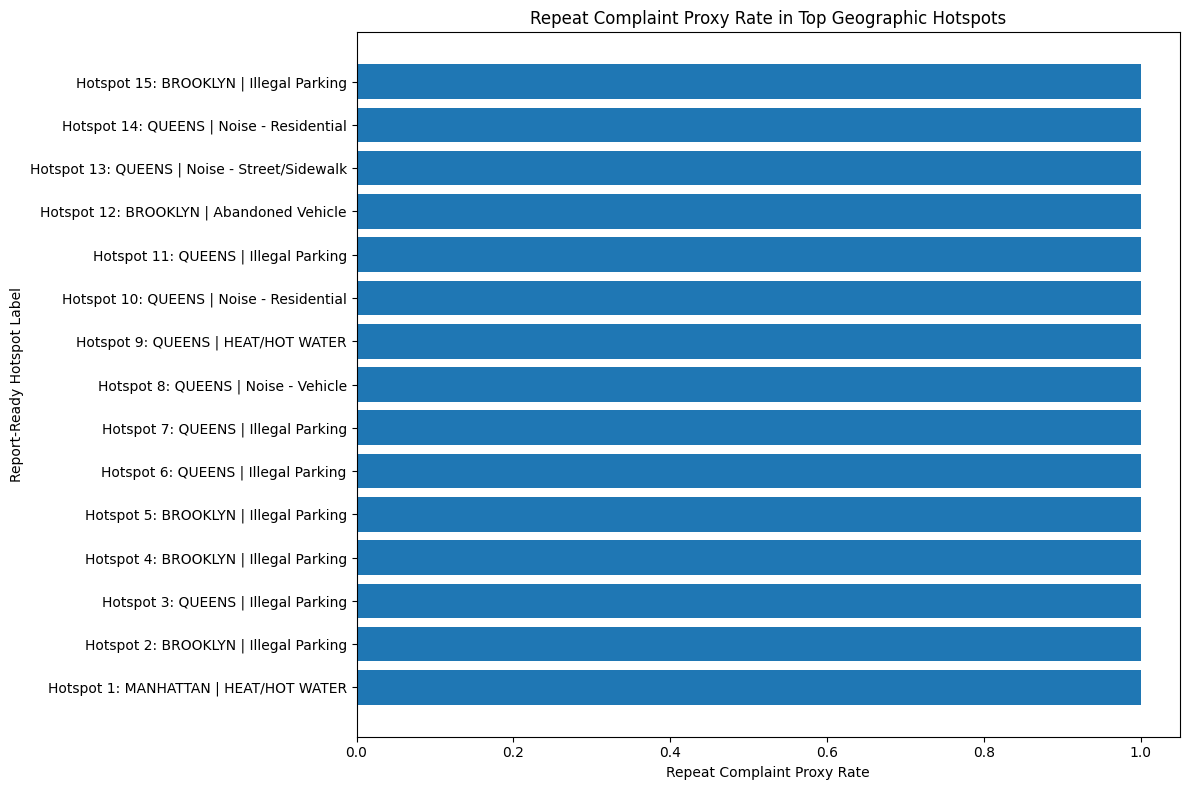

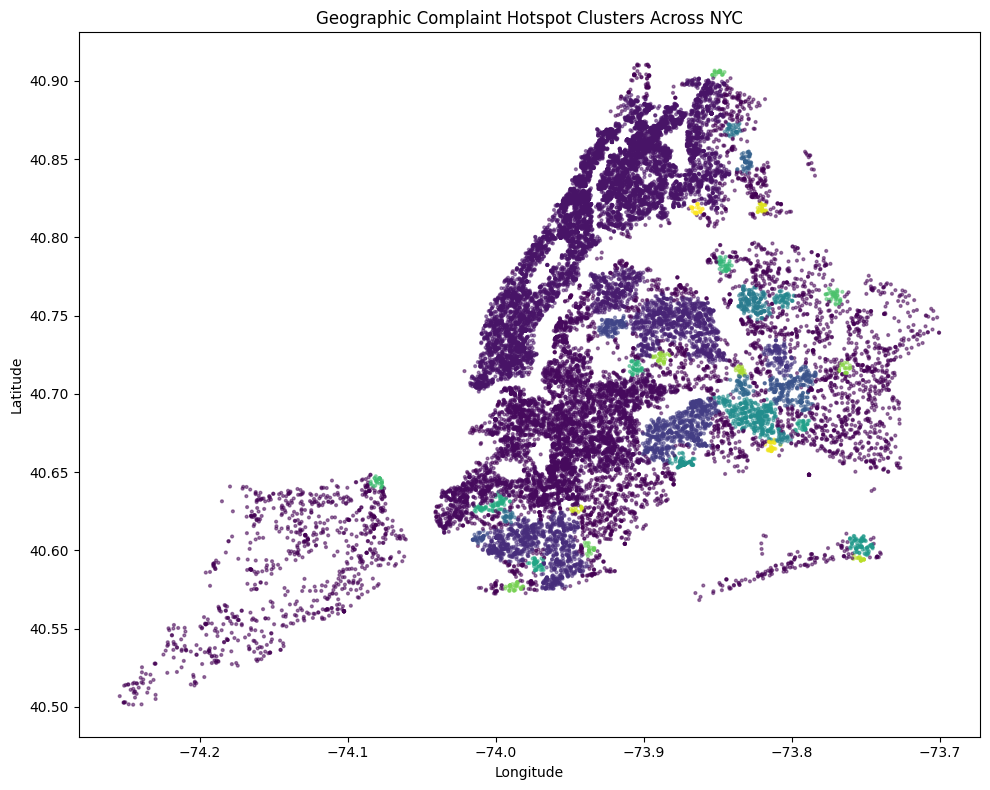

In [ ]:
# Step 6: Geographic report-ready plots

if len(geo_summary) > 0:
    top_geo = geo_summary.head(15).copy().sort_values("complaint_count")

    plt.figure(figsize=(12, 8))
    plt.barh(top_geo["geo_hotspot_label"], top_geo["complaint_count"])
    plt.title("Top Geographic Complaint Hotspots by Complaint Volume")
    plt.xlabel("Complaint Count in Clustering Sample")
    plt.ylabel("Report-Ready Hotspot Label")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "geo_hotspot_top15_report_labels.png", dpi=200)
    plt.savefig(PLOT_DIR / "geo_cluster_top15_counts.png", dpi=200)
    plt.show()

    top_geo_repeat = geo_summary.head(15).copy().sort_values("repeat_proxy_rate")
    plt.figure(figsize=(12, 8))
    plt.barh(top_geo_repeat["geo_hotspot_label"], top_geo_repeat["repeat_proxy_rate"])
    plt.title("Repeat Complaint Proxy Rate in Top Geographic Hotspots")
    plt.xlabel("Repeat Complaint Proxy Rate")
    plt.ylabel("Report-Ready Hotspot Label")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "geo_hotspot_repeat_proxy_report_labels.png", dpi=200)
    plt.savefig(PLOT_DIR / "repeat_proxy_by_geo_cluster.png", dpi=200)
    plt.show()

    plot_geo = geo_sample.copy()
    if len(plot_geo) > 30000:
        plot_geo = plot_geo.sample(30000, random_state=42)

    plt.figure(figsize=(10, 8))
    plt.scatter(plot_geo["longitude"], plot_geo["latitude"], c=plot_geo["geo_cluster_id"], s=4, alpha=0.5)
    plt.title("Geographic Complaint Hotspot Clusters Across NYC")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "geo_dbscan_scatter.png", dpi=200)
    plt.show()
else:
    print("Skipping geographic plots because no non-noise geographic clusters were produced.")

## Step 7: Operational segmentation clustering

This section creates operational segments using response time, same-day closure behavior, repeat proxy behavior, time features, complaint type, borough, and agency. The output is not just a cluster number. Each cluster is translated into a report-ready operational segment name.

In [ ]:
# Step 7: Build operational clustering sample and features

MAX_OPERATIONAL_ROWS = 100000
op = work.copy()

# Fill numeric features.
for col in ["closed_same_day_flag", "repeat_complaint_proxy_combined", "created_hour", "created_dayofweek", "created_month"]:
    if col not in op.columns:
        op[col] = 0
    op[col] = pd.to_numeric(op[col], errors="coerce").fillna(0)

# Keep only common categories to avoid very wide sparse matrices.
for cat_col in ["complaint_type", "borough", "agency"]:
    top_values = op[cat_col].value_counts().head(30).index
    op[cat_col + "_cluster"] = np.where(op[cat_col].isin(top_values), op[cat_col], "OTHER")

needed = [
    "log_response_time_hours", "closed_same_day_flag", "repeat_complaint_proxy_combined",
    "created_hour", "created_dayofweek", "created_month",
    "complaint_type_cluster", "borough_cluster", "agency_cluster"
]
op = op.dropna(subset=["log_response_time_hours"]).copy()

if len(op) > MAX_OPERATIONAL_ROWS:
    op_sample = op.sample(MAX_OPERATIONAL_ROWS, random_state=42).copy()
else:
    op_sample = op.copy()

numeric_features = [
    "log_response_time_hours", "closed_same_day_flag", "repeat_complaint_proxy_combined",
    "created_hour", "created_dayofweek", "created_month"
]
categorical_features = ["complaint_type_cluster", "borough_cluster", "agency_cluster"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X = preprocess.fit_transform(op_sample[needed])
print(f"Operational clustering matrix shape: {X.shape}")

Operational clustering matrix shape: (100000, 57)


,k,silhouette_score
0,3,0.247308
1,4,0.246152
2,5,0.180856
3,6,0.136435
4,7,0.156675
5,8,0.154961


Selected operational segment count: 3


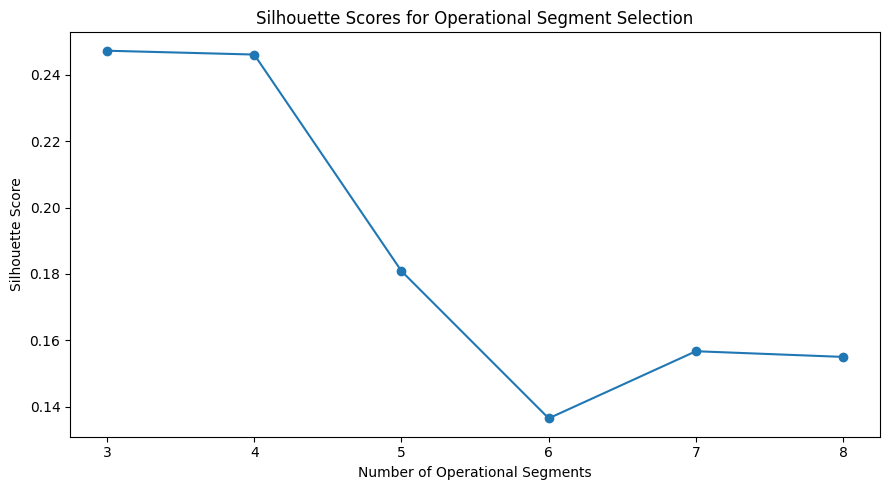

In [ ]:
# Step 8: Select the number of operational segments using silhouette scores

candidate_ks = [3, 4, 5, 6, 7, 8]
silhouette_rows = []

# Silhouette can be expensive, so score on a smaller random subset when needed.
score_sample_size = min(10000, X.shape[0])
rng = np.random.default_rng(42)
score_idx = rng.choice(X.shape[0], size=score_sample_size, replace=False) if X.shape[0] > score_sample_size else np.arange(X.shape[0])
X_score = X[score_idx]

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    try:
        score = silhouette_score(X_score, labels[score_idx])
    except Exception:
        score = np.nan
    silhouette_rows.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_rows)
silhouette_df.to_csv(TABLE_DIR / "operational_cluster_silhouette_scores.csv", index=False)
display(silhouette_df)

valid_scores = silhouette_df.dropna()
best_k = int(valid_scores.sort_values("silhouette_score", ascending=False).iloc[0]["k"]) if len(valid_scores) else 5
print(f"Selected operational segment count: {best_k}")

plt.figure(figsize=(9, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Scores for Operational Segment Selection")
plt.xlabel("Number of Operational Segments")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_silhouette_scores.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_silhouette_scores.png", dpi=200)
plt.show()

In [ ]:
# Step 9: Fit final operational clustering model and create PCA coordinates

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
op_sample["operational_cluster_id"] = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)
op_sample["pca_1"] = pca_coords[:, 0]
op_sample["pca_2"] = pca_coords[:, 1]

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

PCA explained variance ratio: [0.25064709 0.12315893]


In [ ]:
# Step 10: Create report-ready operational segment names and summaries

def mode_or_unknown(x):
    m = x.mode(dropna=True)
    return m.iloc[0] if len(m) else "UNKNOWN"

op_summary = (
    op_sample
    .groupby("operational_cluster_id")
    .agg(
        complaint_count=("complaint_type", "size"),
        avg_response_time_hours=("response_time_hours", "mean"),
        median_response_time_hours=("response_time_hours", "median"),
        same_day_closure_rate=("closed_same_day_flag", "mean"),
        repeat_proxy_rate=("repeat_complaint_proxy_combined", "mean"),
        top_complaint_type=("complaint_type", mode_or_unknown),
        top_borough=("borough", mode_or_unknown),
        top_agency=("agency", mode_or_unknown)
    )
    .reset_index()
)

# Relative thresholds make labels adapt to the actual output data.
rt_high = op_summary["avg_response_time_hours"].quantile(0.67)
rt_low = op_summary["avg_response_time_hours"].quantile(0.33)
sd_high = op_summary["same_day_closure_rate"].quantile(0.67)
sd_low = op_summary["same_day_closure_rate"].quantile(0.33)
rp_high = op_summary["repeat_proxy_rate"].quantile(0.67)
vol_high = op_summary["complaint_count"].quantile(0.67)

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def profile_name(row):
    if row["avg_response_time_hours"] >= rt_high and row["same_day_closure_rate"] <= sd_low:
        base = "Long Response / Low Closure Segment"
    elif row["repeat_proxy_rate"] >= rp_high and row["complaint_count"] >= vol_high:
        base = "High Recurrence / High Volume Segment"
    elif row["same_day_closure_rate"] >= sd_high and row["avg_response_time_hours"] <= rt_low:
        base = "Fast Closure Segment"
    elif row["repeat_proxy_rate"] >= rp_high:
        base = "Recurring Demand Segment"
    elif row["complaint_count"] >= vol_high:
        base = "High Volume Service Segment"
    else:
        base = "Mixed Operational Segment"
    return base

op_summary["operational_profile"] = op_summary.apply(profile_name, axis=1)
op_summary = op_summary.sort_values(["operational_profile", "complaint_count"], ascending=[True, False]).reset_index(drop=True)
op_summary["segment_letter"] = [letters[i] for i in range(len(op_summary))]
op_summary["operational_segment_name"] = op_summary.apply(
    lambda r: f"Segment {r['segment_letter']}: {r['operational_profile']} | {r['top_complaint_type']} | {r['top_borough']}", axis=1
)

op_summary["management_meaning"] = op_summary.apply(
    lambda r: (
        "Potential management review area because it combines longer response times with weaker same-day closure performance."
        if "Long Response" in r["operational_profile"] else
        "Potential recurring demand area where repeated complaint behavior may require targeted inspection or root-cause review."
        if "Recurrence" in r["operational_profile"] or "Recurring" in r["operational_profile"] else
        "Operationally efficient segment that can be reviewed for practices that support faster closure."
        if "Fast Closure" in r["operational_profile"] else
        "High workload segment that may affect staffing, routing, and service prioritization."
        if "High Volume" in r["operational_profile"] else
        "Mixed segment that may require additional review by complaint type, agency, and borough."
    ), axis=1
)

# Add a priority score for management review.
op_summary["response_time_rank"] = op_summary["avg_response_time_hours"].rank(ascending=False, method="dense")
op_summary["repeat_proxy_rank"] = op_summary["repeat_proxy_rate"].rank(ascending=False, method="dense")
op_summary["same_day_closure_rank"] = op_summary["same_day_closure_rate"].rank(ascending=True, method="dense")
op_summary["management_priority_score"] = (
    op_summary["response_time_rank"] + op_summary["repeat_proxy_rank"] + op_summary["same_day_closure_rank"]
)
op_summary = op_summary.sort_values("management_priority_score").reset_index(drop=True)

# Merge labels back to the record-level sample.
segment_name_map = op_summary.set_index("operational_cluster_id")["operational_segment_name"].to_dict()
segment_profile_map = op_summary.set_index("operational_cluster_id")["operational_profile"].to_dict()
op_sample["operational_segment_name"] = op_sample["operational_cluster_id"].map(segment_name_map)
op_sample["operational_profile"] = op_sample["operational_cluster_id"].map(segment_profile_map)

op_summary.to_csv(TABLE_DIR / "operational_segment_summary_report_ready.csv", index=False)
op_summary.to_csv(TABLE_DIR / "operational_cluster_summary.csv", index=False)
display(op_summary[[
    "operational_segment_name", "complaint_count", "avg_response_time_hours", "same_day_closure_rate",
    "repeat_proxy_rate", "top_complaint_type", "top_borough", "top_agency", "management_priority_score", "management_meaning"
]])

,operational_segment_name,complaint_count,avg_response_time_hours,same_day_closure_rate,repeat_proxy_rate,top_complaint_type,top_borough,top_agency,management_priority_score,management_meaning
0,Segment C: Long Response / Low Closure Segment...,46180,130.147920,0.000000,1.0,HEAT/HOT WATER,BROOKLYN,HPD,3.0,Potential management review area because it co...
1,Segment B: High Recurrence / High Volume Segme...,53817,2.224215,0.999758,1.0,Illegal Parking,BROOKLYN,NYPD,5.0,Potential recurring demand area where repeated...
2,Segment A: Fast Closure Segment | Borough Offi...,3,0.000000,1.000000,0.0,Borough Office,BRONX,DOB,8.0,Operationally efficient segment that can be re...


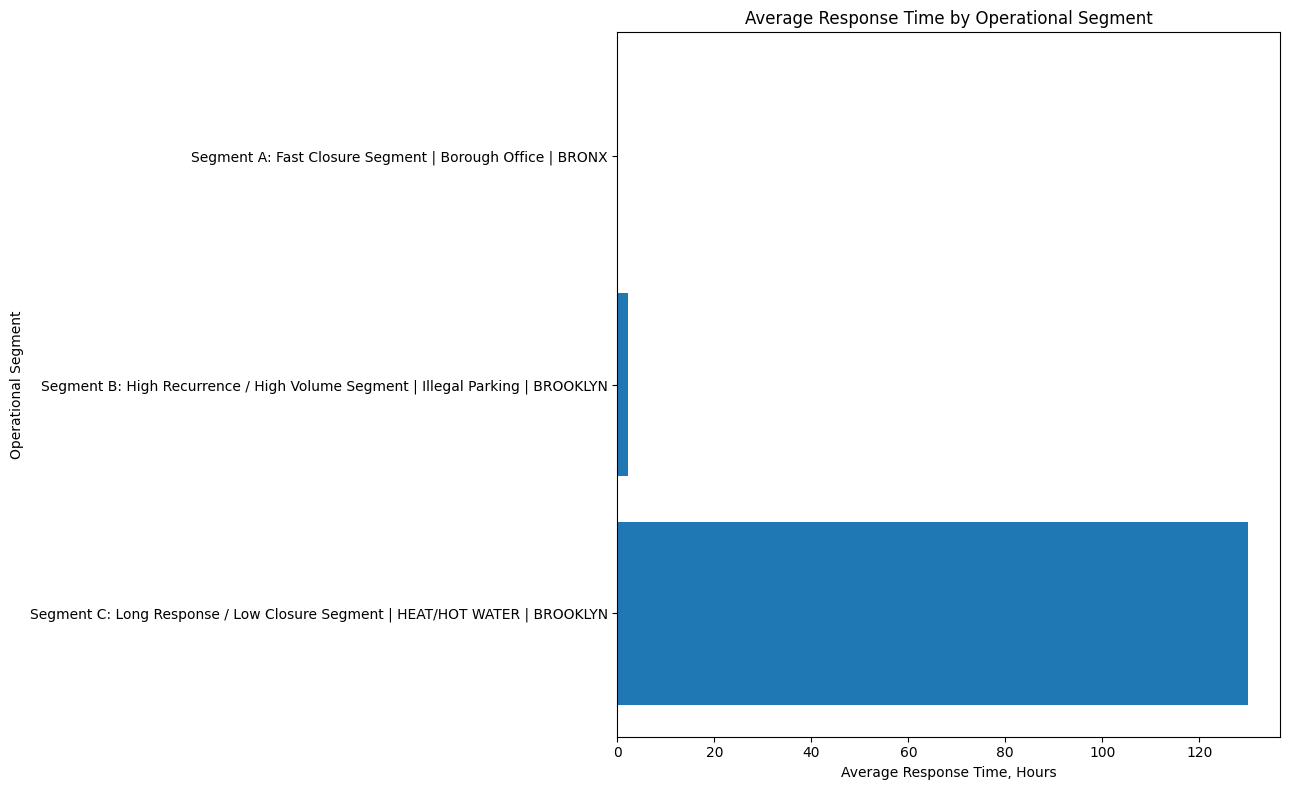

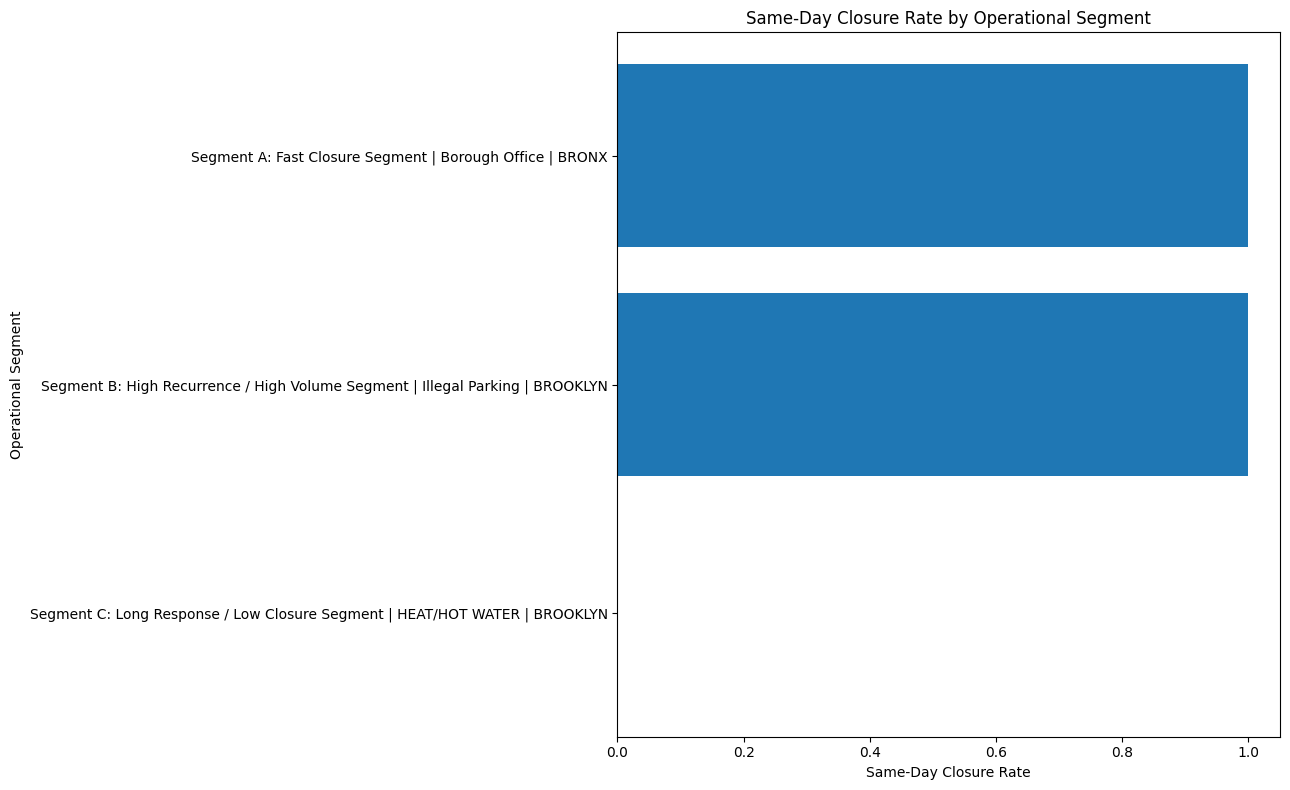

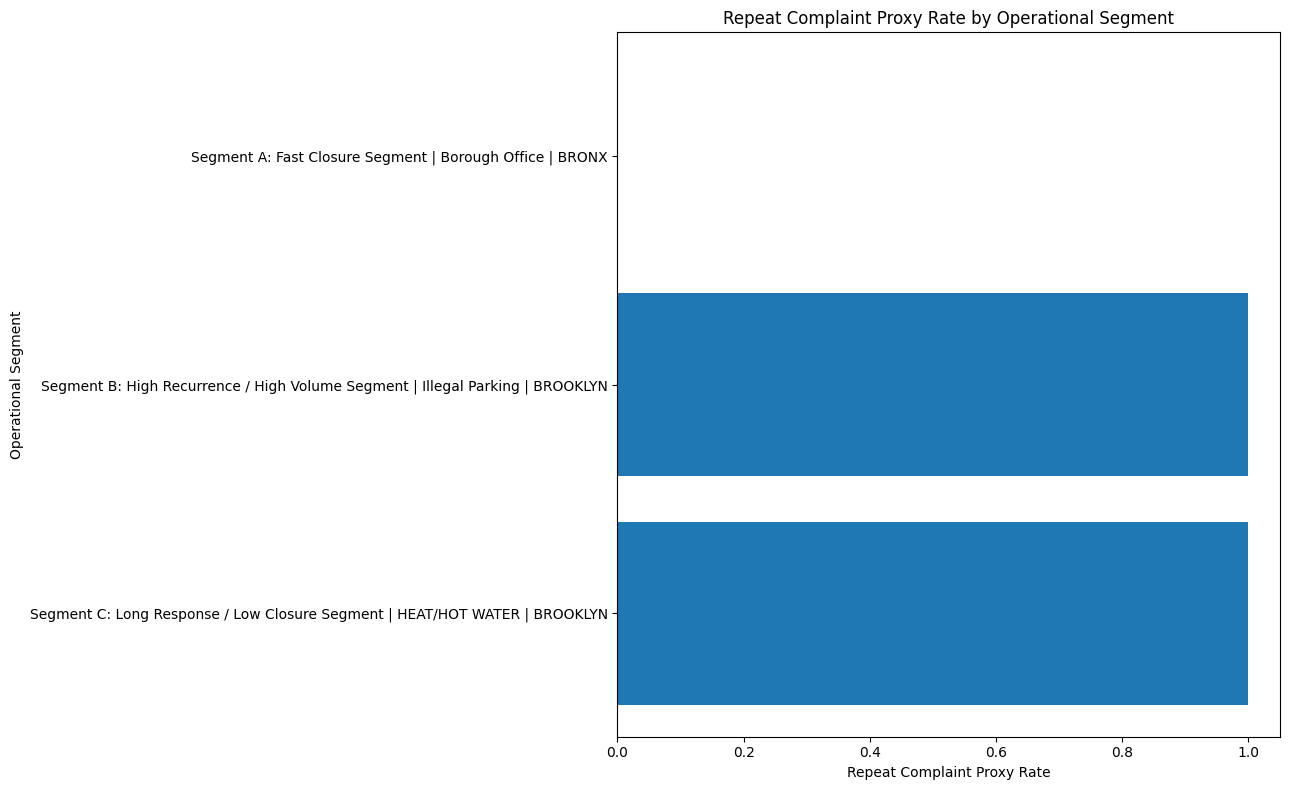

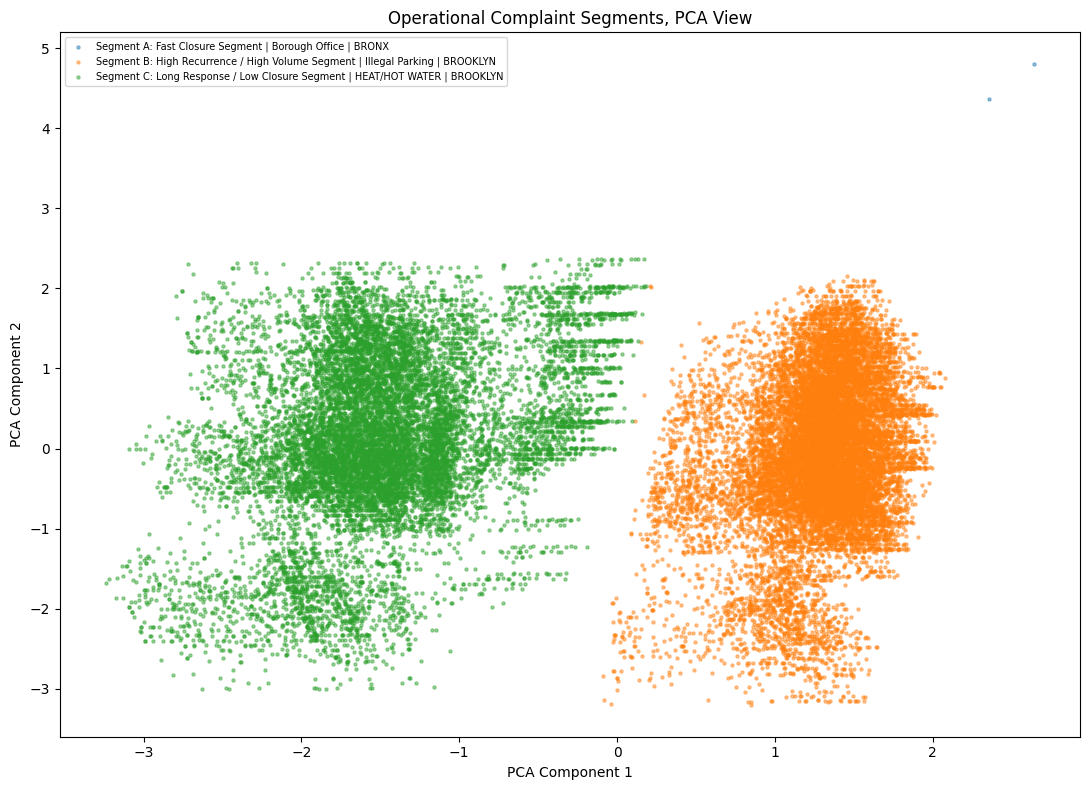

In [ ]:
# Step 11: Operational segment plots

plot_summary = op_summary.sort_values("management_priority_score").copy()

plt.figure(figsize=(13, 8))
plt.barh(plot_summary["operational_segment_name"], plot_summary["avg_response_time_hours"])
plt.title("Average Response Time by Operational Segment")
plt.xlabel("Average Response Time, Hours")
plt.ylabel("Operational Segment")
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_avg_response_time_report_labels.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_avg_response_time.png", dpi=200)
plt.show()

plt.figure(figsize=(13, 8))
plt.barh(plot_summary["operational_segment_name"], plot_summary["same_day_closure_rate"])
plt.title("Same-Day Closure Rate by Operational Segment")
plt.xlabel("Same-Day Closure Rate")
plt.ylabel("Operational Segment")
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_same_day_rate_report_labels.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_same_day_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(13, 8))
plt.barh(plot_summary["operational_segment_name"], plot_summary["repeat_proxy_rate"])
plt.title("Repeat Complaint Proxy Rate by Operational Segment")
plt.xlabel("Repeat Complaint Proxy Rate")
plt.ylabel("Operational Segment")
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_repeat_proxy_rate_report_labels.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_repeat_proxy_rate.png", dpi=200)
plt.show()

plot_op = op_sample.copy()
if len(plot_op) > 30000:
    plot_op = plot_op.sample(30000, random_state=42)

plt.figure(figsize=(11, 8))
for name, grp in plot_op.groupby("operational_segment_name"):
    plt.scatter(grp["pca_1"], grp["pca_2"], s=5, alpha=0.45, label=name)
plt.title("Operational Complaint Segments, PCA View")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_pca_scatter_report_labels.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_pca_scatter.png", dpi=200)
plt.show()

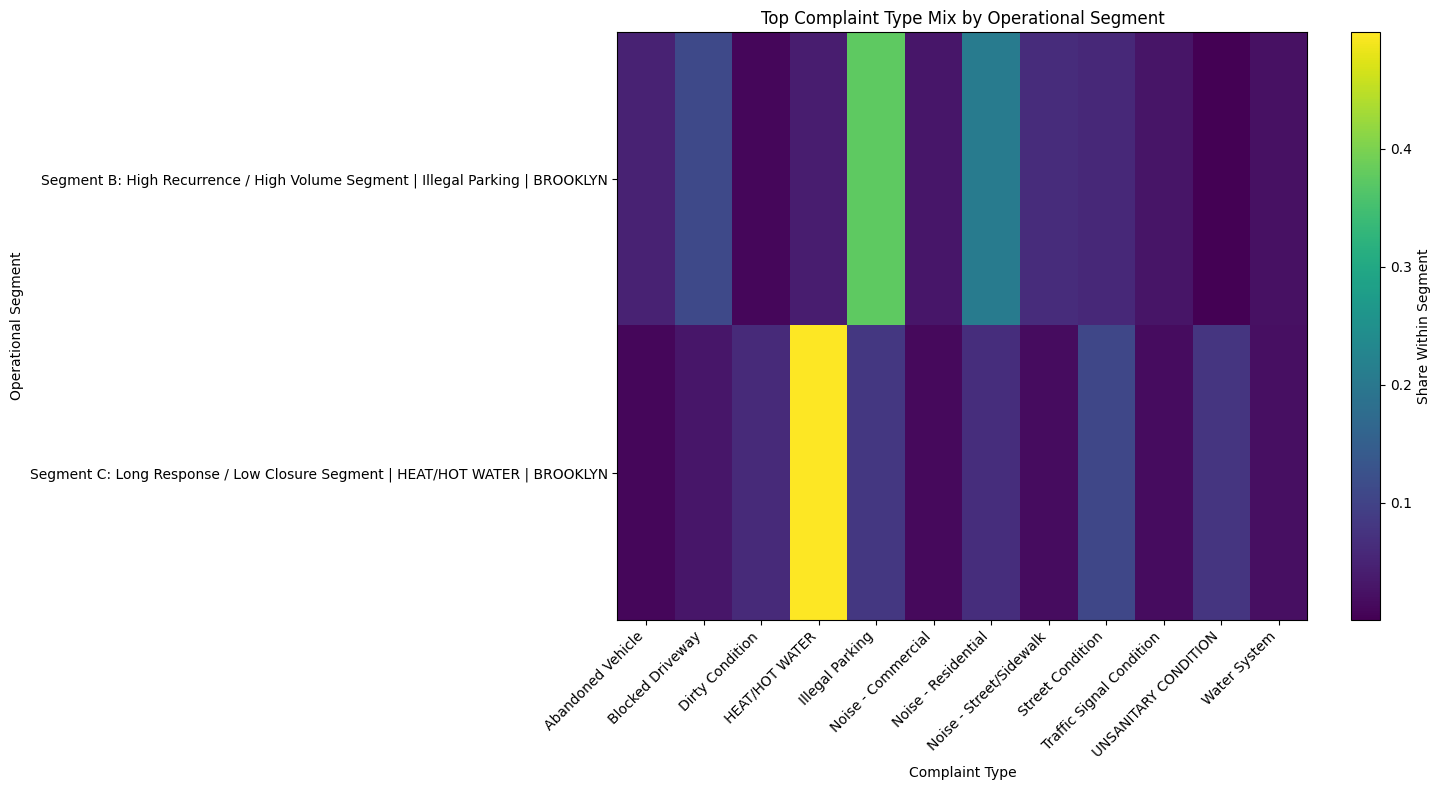

In [ ]:
# Step 12: Complaint type heatmap by operational segment

# Use top complaint types overall for a compact report-ready heatmap.
top_complaints = op_sample["complaint_type"].value_counts().head(12).index
heat = (
    op_sample[op_sample["complaint_type"].isin(top_complaints)]
    .groupby(["operational_segment_name", "complaint_type"])
    .size()
    .unstack(fill_value=0)
)

heat_pct = heat.div(heat.sum(axis=1), axis=0).fillna(0)
heat_pct.to_csv(TABLE_DIR / "operational_segment_complaint_type_heatmap_values.csv")
heat_pct.to_csv(TABLE_DIR / "operational_cluster_complaint_type_heatmap_values.csv")

plt.figure(figsize=(15, 8))
plt.imshow(heat_pct.values, aspect="auto")
plt.colorbar(label="Share Within Segment")
plt.title("Top Complaint Type Mix by Operational Segment")
plt.xlabel("Complaint Type")
plt.ylabel("Operational Segment")
plt.xticks(range(len(heat_pct.columns)), heat_pct.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_pct.index)), heat_pct.index)
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segment_complaint_type_heatmap_report_labels.png", dpi=200)
plt.savefig(PLOT_DIR / "operational_cluster_complaint_type_heatmap.png", dpi=200)
plt.show()

## Step 13: Management interpretation

This step produces the most important tables for the report. The output translates clustering results into management language. The goal is to help the reader understand what each segment means rather than only seeing arbitrary cluster numbers.

In [ ]:
# Step 13: Management-facing findings table and report inventory

management_findings = op_summary.copy()
management_findings["report_finding"] = management_findings.apply(
    lambda r: (
        f"{r['operational_segment_name']} includes {int(r['complaint_count']):,} sampled complaints. "
        f"The leading complaint type is {r['top_complaint_type']}, the leading borough is {r['top_borough']}, "
        f"and the leading agency is {r['top_agency']}. The segment has an average response time of "
        f"{r['avg_response_time_hours']:.1f} hours, a same-day closure rate of {r['same_day_closure_rate']:.1%}, "
        f"and a repeat complaint proxy rate of {r['repeat_proxy_rate']:.1%}. Management meaning: {r['management_meaning']}"
    ), axis=1
)

management_findings.to_csv(TABLE_DIR / "notebook4_management_findings_table.csv", index=False)
management_findings.to_csv(REPORT_DIR / "report_ready_management_findings.csv", index=False)

display(management_findings[[
    "operational_segment_name", "complaint_count", "avg_response_time_hours", "same_day_closure_rate",
    "repeat_proxy_rate", "top_complaint_type", "top_borough", "top_agency", "management_meaning", "report_finding"
]])

# Create top complaint types within each segment.
op_cluster_complaints = (
    op_sample
    .groupby(["operational_segment_name", "complaint_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["operational_segment_name", "count"], ascending=[True, False])
)
op_cluster_complaints.to_csv(TABLE_DIR / "operational_segment_top_complaint_types.csv", index=False)
op_cluster_complaints.to_csv(TABLE_DIR / "operational_cluster_top_complaint_types.csv", index=False)

# Create borough mix within each segment.
op_cluster_borough = (
    op_sample
    .groupby(["operational_segment_name", "borough"])
    .size()
    .reset_index(name="count")
    .sort_values(["operational_segment_name", "count"], ascending=[True, False])
)
op_cluster_borough.to_csv(TABLE_DIR / "operational_segment_borough_mix.csv", index=False)
op_cluster_borough.to_csv(TABLE_DIR / "operational_cluster_borough_mix.csv", index=False)

# Report inventory tells the writer exactly which files to include.
report_inventory = pd.DataFrame([
    {
        "filename": "plots/operational_segment_avg_response_time_report_labels.png",
        "report_use": "Shows which operational segments have the longest average response time. Use in the results section to discuss operational strain."
    },
    {
        "filename": "plots/operational_segment_same_day_rate_report_labels.png",
        "report_use": "Shows same-day closure differences across meaningful operational segments. Use to connect clustering with the Notebook 3 classification target."
    },
    {
        "filename": "plots/operational_segment_repeat_proxy_rate_report_labels.png",
        "report_use": "Shows which operational segments have higher recurring complaint behavior. Use for management recommendations."
    },
    {
        "filename": "plots/operational_segment_complaint_type_heatmap_report_labels.png",
        "report_use": "Shows the complaint type composition of each segment. Use to explain what each segment represents."
    },
    {
        "filename": "plots/operational_segment_pca_scatter_report_labels.png",
        "report_use": "Shows how complaints separate into operational segments in reduced feature space. Use as the main clustering methodology figure."
    },
    {
        "filename": "plots/geo_hotspot_top15_report_labels.png",
        "report_use": "Shows the highest volume geographic hotspots with report-ready labels. Use for geographic operational findings."
    },
    {
        "filename": "plots/geo_hotspot_repeat_proxy_report_labels.png",
        "report_use": "Shows repeat complaint proxy rates among top geographic hotspots. Use for recurring service demand discussion."
    },
    {
        "filename": "plots/geo_dbscan_scatter.png",
        "report_use": "Shows the geographic distribution of DBSCAN hotspot clusters. Use as a technical geographic clustering figure."
    },
    {
        "filename": "tables/operational_segment_summary_report_ready.csv",
        "report_use": "Main table for describing each operational segment with management meaning."
    },
    {
        "filename": "tables/notebook4_management_findings_table.csv",
        "report_use": "Main management findings table with narrative-ready findings."
    },
    {
        "filename": "tables/geo_cluster_summary_report_ready.csv",
        "report_use": "Main geographic hotspot table with hotspot labels, complaint counts, repeat proxy rates, and management meaning."
    }
])
report_inventory.to_csv(REPORT_DIR / "report_figure_and_table_inventory.csv", index=False)
display(report_inventory)

,operational_segment_name,complaint_count,avg_response_time_hours,same_day_closure_rate,repeat_proxy_rate,top_complaint_type,top_borough,top_agency,management_meaning,report_finding
0,Segment C: Long Response / Low Closure Segment...,46180,130.147920,0.000000,1.0,HEAT/HOT WATER,BROOKLYN,HPD,Potential management review area because it co...,Segment C: Long Response / Low Closure Segment...
1,Segment B: High Recurrence / High Volume Segme...,53817,2.224215,0.999758,1.0,Illegal Parking,BROOKLYN,NYPD,Potential recurring demand area where repeated...,Segment B: High Recurrence / High Volume Segme...
2,Segment A: Fast Closure Segment | Borough Offi...,3,0.000000,1.000000,0.0,Borough Office,BRONX,DOB,Operationally efficient segment that can be re...,Segment A: Fast Closure Segment | Borough Offi...


,filename,report_use
0,plots/operational_segment_avg_response_time_re...,Shows which operational segments have the long...
1,plots/operational_segment_same_day_rate_report...,Shows same-day closure differences across mean...
2,plots/operational_segment_repeat_proxy_rate_re...,Shows which operational segments have higher r...
3,plots/operational_segment_complaint_type_heatm...,Shows the complaint type composition of each s...
4,plots/operational_segment_pca_scatter_report_l...,Shows how complaints separate into operational...
5,plots/geo_hotspot_top15_report_labels.png,Shows the highest volume geographic hotspots w...
6,plots/geo_hotspot_repeat_proxy_report_labels.png,Shows repeat complaint proxy rates among top g...
7,plots/geo_dbscan_scatter.png,Shows the geographic distribution of DBSCAN ho...
8,tables/operational_segment_summary_report_read...,Main table for describing each operational seg...
9,tables/notebook4_management_findings_table.csv,Main management findings table with narrative-...


In [ ]:
# Step 14: Export enhanced sample with operational labels

cluster_export_cols = [
    "unique_key", "created_date", "closed_date", "complaint_type", "descriptor", "borough", "agency", "agency_name",
    "latitude", "longitude", "incident_zip", "response_time_hours", "closed_same_day_flag",
    "repeat_complaint_flag", "repeat_complaint_proxy_combined", "complaint_geo_month_count",
    "operational_cluster_id", "operational_segment_name", "operational_profile", "pca_1", "pca_2"
]
cluster_export_cols = [c for c in cluster_export_cols if c in op_sample.columns]

enhanced_cluster_sample = op_sample[cluster_export_cols].copy()
enhanced_cluster_sample.to_parquet(DATA_DIR / "analysis_ready_sample_with_operational_segments.parquet", index=False)
enhanced_cluster_sample.head(5000).to_csv(DATA_DIR / "analysis_ready_sample_with_operational_segments_preview.csv", index=False)

# Also save legacy-compatible names.
enhanced_cluster_sample.to_parquet(DATA_DIR / "analysis_ready_sample_with_operational_clusters.parquet", index=False)
enhanced_cluster_sample.head(5000).to_csv(DATA_DIR / "analysis_ready_sample_with_operational_clusters_preview.csv", index=False)

print("Saved enhanced clustered sample files with meaningful operational segment labels.")
display(enhanced_cluster_sample.head())

Saved enhanced clustered sample files with meaningful operational segment labels.


,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,latitude,longitude,incident_zip,response_time_hours,closed_same_day_flag,repeat_complaint_flag,repeat_complaint_proxy_combined,complaint_geo_month_count,operational_cluster_id,operational_segment_name,operational_profile,pca_1,pca_2
144365,68347683,2026-03-16 22:27:06,2026-03-17 00:44:37,Illegal Parking,Commercial Overnight Parking,BROOKLYN,NYPD,New York City Police Department,40.609717,-73.9326,11234.0,2.291944,0,1,1,4,2,Segment C: Long Response / Low Closure Segment...,Long Response / Low Closure Segment,-0.267108,-0.067309
2709,68384082,2026-03-19 15:18:44,2026-03-19 20:54:04,Abandoned Vehicle,With License Plate,BROOKLYN,NYPD,New York City Police Department,40.667754,-73.944657,11213.0,5.588889,1,1,1,1,0,Segment B: High Recurrence / High Volume Segme...,High Recurrence / High Volume Segment,0.931713,0.309157
74713,68473002,2026-03-27 05:40:57,2026-03-27 05:44:18,Noise - Commercial,Loud Talking,BRONX,NYPD,New York City Police Department,40.828501,-73.880327,10472.0,0.055833,1,1,1,1,0,Segment B: High Recurrence / High Volume Segme...,High Recurrence / High Volume Segment,1.773266,0.050722
44665,68504028,2026-03-30 10:35:11,2026-03-31 00:00:00,Building/Use,Illegal Conversion Of Residential Building/Space,QUEENS,DOB,Department of Buildings,40.724451,-73.883177,11379.0,13.413611,0,1,1,4,2,Segment C: Long Response / Low Closure Segment...,Long Response / Low Closure Segment,-0.881306,-0.818993
73400,67323542,2025-12-29 03:31:00,2026-01-05 13:09:00,Street Light Condition,Street Light Out,BRONX,DOT,Department of Transportation,40.824083,-73.842899,10473.0,177.633333,0,1,1,1,2,Segment C: Long Response / Low Closure Segment...,Long Response / Low Closure Segment,-2.004535,-2.819711


## Step 16: Operational Trend Analysis

This section extends the clustering results into management-focused trend analysis. The purpose is not to create generic monthly complaint totals. The goal is to track how operational segments, repeat complaint behavior, response times, and geographic hotspots change over time.

These outputs help answer management questions such as:

- Which operational segments are growing in volume?
- Which segments are showing worsening response time behavior?
- Are repeat complaint patterns increasing in specific operational segments?
- Which geographic hotspots appear to be emerging or expanding?
- Which complaint types are trending upward within the clustering sample?

The trend outputs are intended to support resource planning, inspection prioritization, staffing review, and mayoral-level service improvement decisions.

Trend analysis rows available: 100,000
Months covered: 2025-12-01 to 2026-04-01
Top operational segments included in trend plots:
- Segment B: High Recurrence / High Volume Segment | Illegal Parking | BROOKLYN
- Segment C: Long Response / Low Closure Segment | HEAT/HOT WATER | BROOKLYN
- Segment A: Fast Closure Segment | Borough Office | BRONX


,created_month_start,operational_segment_name,complaint_count
0,2025-12-01,Segment B: High Recurrence / High Volume Segme...,6921
1,2025-12-01,Segment C: Long Response / Low Closure Segment...,9476
2,2026-01-01,Segment B: High Recurrence / High Volume Segme...,9220
3,2026-01-01,Segment C: Long Response / Low Closure Segment...,11876
4,2026-03-01,Segment A: Fast Closure Segment | Borough Offi...,1
5,2026-03-01,Segment B: High Recurrence / High Volume Segme...,31967
6,2026-03-01,Segment C: Long Response / Low Closure Segment...,23264
7,2026-04-01,Segment A: Fast Closure Segment | Borough Offi...,2
8,2026-04-01,Segment B: High Recurrence / High Volume Segme...,5709
9,2026-04-01,Segment C: Long Response / Low Closure Segment...,1564


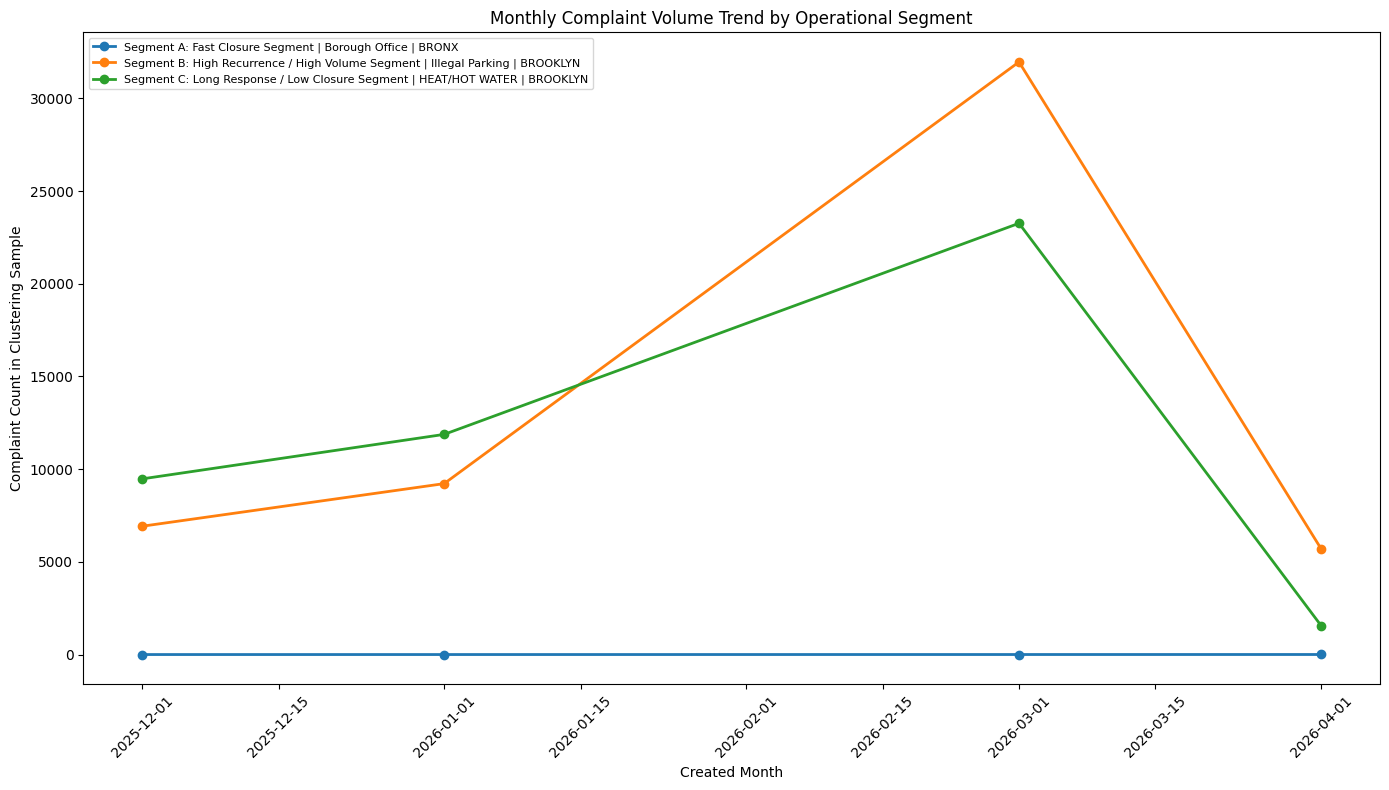

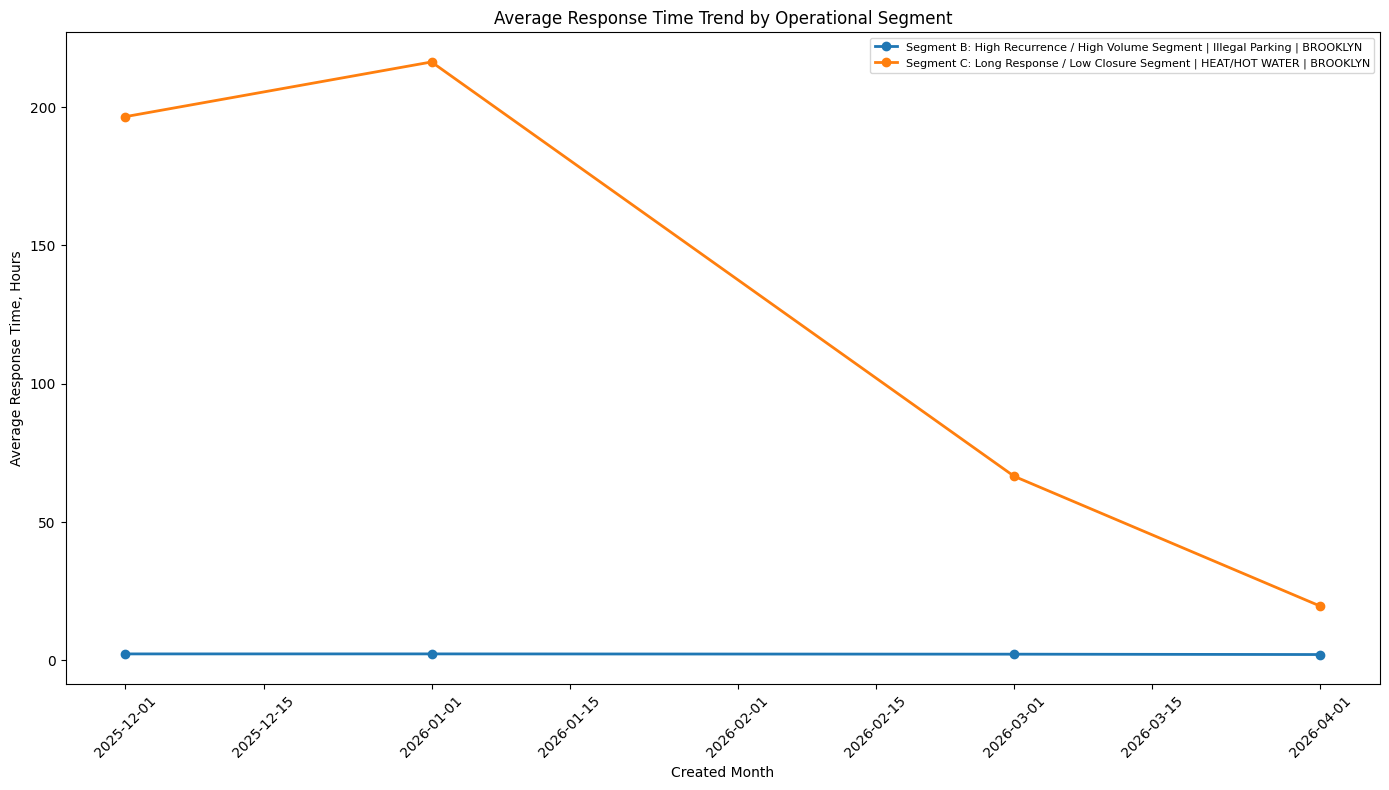

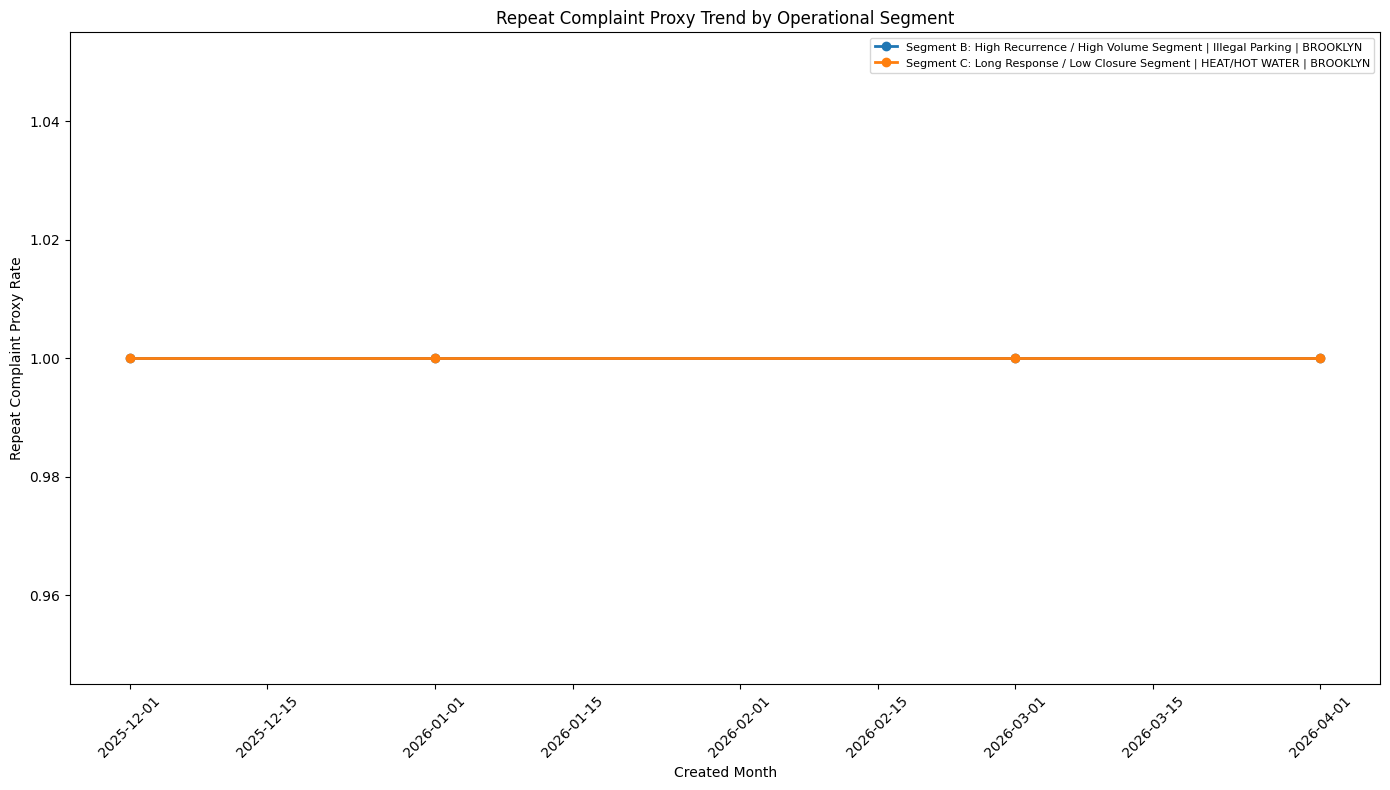

Complaint type growth comparison skipped because fewer than six months are available.
Geographic hotspot growth comparison skipped because fewer than six months are available.


,trend_area,finding,management_value,supporting_file
0,Trend Analysis,"Trend analysis completed, but the dataset did ...",This still confirms whether the clustering sam...,tables/trend_operational_segment_monthly_volum...


,filename,report_use
11,plots/trend_operational_segment_monthly_volume...,Shows which operational segments are increasin...
12,plots/trend_operational_segment_avg_response_t...,Shows whether response times are improving or ...
13,plots/trend_operational_segment_repeat_proxy_r...,Shows whether recurring complaint behavior is ...
14,plots/trend_top_complaint_type_growth.png,Shows which complaint types increased most in ...
15,plots/trend_emerging_geo_hotspot_growth.png,Shows which geographic hotspots are emerging o...
16,tables/trend_management_findings_summary.csv,Main trend findings table with management inte...
17,tables/trend_operational_segment_growth_summar...,Table comparing latest three months with the p...
18,tables/trend_complaint_type_growth_summary.csv,Table comparing latest three months with the p...
19,tables/trend_emerging_geo_hotspot_growth.csv,Table comparing latest three months with the p...


Trend analysis completed. Main trend outputs:
- tables/trend_operational_segment_monthly_volume.csv
- plots/trend_operational_segment_monthly_volume.png
- tables/trend_operational_segment_avg_response_time.csv
- plots/trend_operational_segment_avg_response_time.png
- tables/trend_operational_segment_repeat_proxy_rate.csv
- plots/trend_operational_segment_repeat_proxy_rate.png
- tables/trend_geo_hotspot_monthly_volume.csv


In [ ]:
# Step 16: Operational trend analysis and management-facing trend outputs

# Trend analysis works from the operational clustering sample already created above.
# It uses segment labels instead of raw cluster IDs so that the plots are meaningful in the report.

trend_outputs = []
trend_findings_rows = []

def save_display_table(df_obj, path):
    df_obj.to_csv(path, index=False)
    display(df_obj.head(20))

def safe_pct_change(new, old):
    if pd.isna(old) or old == 0:
        return np.nan
    return (new - old) / old

# Validate dates for trend analysis.
if "created_date" not in op_sample.columns:
    print("Trend analysis skipped because created_date is not available in the operational sample.")
else:
    trend = op_sample.copy()
    trend["created_date"] = pd.to_datetime(trend["created_date"], errors="coerce")
    trend = trend.dropna(subset=["created_date"]).copy()

    if trend.empty:
        print("Trend analysis skipped because no valid created_date values were available.")
    else:
        trend["created_month_start"] = trend["created_date"].dt.to_period("M").dt.to_timestamp()
        trend["response_time_hours"] = pd.to_numeric(trend["response_time_hours"], errors="coerce")
        trend["repeat_complaint_proxy_combined"] = pd.to_numeric(
            trend.get("repeat_complaint_proxy_combined", 0), errors="coerce"
        ).fillna(0)
        trend["closed_same_day_flag"] = pd.to_numeric(
            trend.get("closed_same_day_flag", 0), errors="coerce"
        ).fillna(0)

        # Keep the most important segments readable in line plots.
        top_segments = (
            trend["operational_segment_name"]
            .value_counts()
            .head(6)
            .index
            .tolist()
        )
        trend_top = trend[trend["operational_segment_name"].isin(top_segments)].copy()

        print(f"Trend analysis rows available: {len(trend):,}")
        print(f"Months covered: {trend['created_month_start'].min().date()} to {trend['created_month_start'].max().date()}")
        print("Top operational segments included in trend plots:")
        for seg in top_segments:
            print(f"- {seg}")

        # 1. Monthly complaint volume by operational segment.
        segment_monthly_volume = (
            trend_top
            .groupby(["created_month_start", "operational_segment_name"])
            .size()
            .reset_index(name="complaint_count")
            .sort_values(["created_month_start", "operational_segment_name"])
        )
        save_display_table(segment_monthly_volume, TABLE_DIR / "trend_operational_segment_monthly_volume.csv")
        trend_outputs.append("tables/trend_operational_segment_monthly_volume.csv")

        if not segment_monthly_volume.empty:
            pivot_volume = segment_monthly_volume.pivot(
                index="created_month_start",
                columns="operational_segment_name",
                values="complaint_count"
            ).fillna(0)

            plt.figure(figsize=(14, 8))
            for col in pivot_volume.columns:
                plt.plot(pivot_volume.index, pivot_volume[col], marker="o", linewidth=2, label=col)
            plt.title("Monthly Complaint Volume Trend by Operational Segment")
            plt.xlabel("Created Month")
            plt.ylabel("Complaint Count in Clustering Sample")
            plt.xticks(rotation=45)
            plt.legend(loc="best", fontsize=8)
            plt.tight_layout()
            plt.savefig(PLOT_DIR / "trend_operational_segment_monthly_volume.png", dpi=200)
            plt.show()
            trend_outputs.append("plots/trend_operational_segment_monthly_volume.png")

        # 2. Average response time trend by operational segment.
        response_trend = (
            trend_top
            .groupby(["created_month_start", "operational_segment_name"])
            .agg(
                avg_response_time_hours=("response_time_hours", "mean"),
                complaint_count=("response_time_hours", "size")
            )
            .reset_index()
        )
        # Hide very sparse monthly segment points from the plot, but keep full table.
        response_trend.to_csv(TABLE_DIR / "trend_operational_segment_avg_response_time.csv", index=False)
        trend_outputs.append("tables/trend_operational_segment_avg_response_time.csv")
        response_plot = response_trend[response_trend["complaint_count"] >= 20].copy()

        if not response_plot.empty:
            pivot_response = response_plot.pivot(
                index="created_month_start",
                columns="operational_segment_name",
                values="avg_response_time_hours"
            )

            plt.figure(figsize=(14, 8))
            for col in pivot_response.columns:
                plt.plot(pivot_response.index, pivot_response[col], marker="o", linewidth=2, label=col)
            plt.title("Average Response Time Trend by Operational Segment")
            plt.xlabel("Created Month")
            plt.ylabel("Average Response Time, Hours")
            plt.xticks(rotation=45)
            plt.legend(loc="best", fontsize=8)
            plt.tight_layout()
            plt.savefig(PLOT_DIR / "trend_operational_segment_avg_response_time.png", dpi=200)
            plt.show()
            trend_outputs.append("plots/trend_operational_segment_avg_response_time.png")
        else:
            print("Average response time trend plot skipped because monthly segment counts were too sparse.")

        # 3. Repeat complaint proxy trend by operational segment.
        repeat_trend = (
            trend_top
            .groupby(["created_month_start", "operational_segment_name"])
            .agg(
                repeat_proxy_rate=("repeat_complaint_proxy_combined", "mean"),
                complaint_count=("repeat_complaint_proxy_combined", "size")
            )
            .reset_index()
        )
        repeat_trend.to_csv(TABLE_DIR / "trend_operational_segment_repeat_proxy_rate.csv", index=False)
        trend_outputs.append("tables/trend_operational_segment_repeat_proxy_rate.csv")
        repeat_plot = repeat_trend[repeat_trend["complaint_count"] >= 20].copy()

        if not repeat_plot.empty:
            pivot_repeat = repeat_plot.pivot(
                index="created_month_start",
                columns="operational_segment_name",
                values="repeat_proxy_rate"
            )

            plt.figure(figsize=(14, 8))
            for col in pivot_repeat.columns:
                plt.plot(pivot_repeat.index, pivot_repeat[col], marker="o", linewidth=2, label=col)
            plt.title("Repeat Complaint Proxy Trend by Operational Segment")
            plt.xlabel("Created Month")
            plt.ylabel("Repeat Complaint Proxy Rate")
            plt.xticks(rotation=45)
            plt.legend(loc="best", fontsize=8)
            plt.tight_layout()
            plt.savefig(PLOT_DIR / "trend_operational_segment_repeat_proxy_rate.png", dpi=200)
            plt.show()
            trend_outputs.append("plots/trend_operational_segment_repeat_proxy_rate.png")
        else:
            print("Repeat complaint proxy trend plot skipped because monthly segment counts were too sparse.")

        # 4. Trending complaint types, comparing latest three months to prior three months.
        months_sorted = sorted(trend["created_month_start"].dropna().unique())
        complaint_growth_summary = pd.DataFrame()

        if len(months_sorted) >= 6:
            latest_months = months_sorted[-3:]
            prior_months = months_sorted[-6:-3]

            latest_counts = (
                trend[trend["created_month_start"].isin(latest_months)]
                .groupby("complaint_type")
                .size()
                .rename("latest_3_month_count")
            )
            prior_counts = (
                trend[trend["created_month_start"].isin(prior_months)]
                .groupby("complaint_type")
                .size()
                .rename("prior_3_month_count")
            )

            complaint_growth_summary = (
                pd.concat([prior_counts, latest_counts], axis=1)
                .fillna(0)
                .reset_index()
            )
            complaint_growth_summary["absolute_change"] = (
                complaint_growth_summary["latest_3_month_count"] -
                complaint_growth_summary["prior_3_month_count"]
            )
            complaint_growth_summary["percent_change"] = complaint_growth_summary.apply(
                lambda r: safe_pct_change(r["latest_3_month_count"], r["prior_3_month_count"]), axis=1
            )

            # Keep report meaningful by focusing on complaint types with enough latest-period volume.
            complaint_growth_summary = complaint_growth_summary[
                complaint_growth_summary["latest_3_month_count"] >= 25
            ].sort_values(["absolute_change", "latest_3_month_count"], ascending=False)

            complaint_growth_summary.to_csv(TABLE_DIR / "trend_complaint_type_growth_summary.csv", index=False)
            trend_outputs.append("tables/trend_complaint_type_growth_summary.csv")
            display(complaint_growth_summary.head(15))

            if not complaint_growth_summary.empty:
                top_growth = complaint_growth_summary.head(12).sort_values("absolute_change")

                plt.figure(figsize=(12, 8))
                plt.barh(top_growth["complaint_type"], top_growth["absolute_change"])
                plt.title("Complaint Types Trending Upward, Latest Three Months vs Prior Three Months")
                plt.xlabel("Increase in Complaint Count")
                plt.ylabel("Complaint Type")
                plt.tight_layout()
                plt.savefig(PLOT_DIR / "trend_top_complaint_type_growth.png", dpi=200)
                plt.show()
                trend_outputs.append("plots/trend_top_complaint_type_growth.png")
        else:
            print("Complaint type growth comparison skipped because fewer than six months are available.")

        # 5. Emerging geographic hotspot trend analysis.
        # This uses the geographic clustering sample from the prior section when available.
        if "geo_sample" in globals() and "geo_hotspot_label" in geo_sample.columns and "created_date" in geo_sample.columns:
            geo_trend = geo_sample.copy()
            geo_trend["created_date"] = pd.to_datetime(geo_trend["created_date"], errors="coerce")
            geo_trend = geo_trend.dropna(subset=["created_date"]).copy()
            geo_trend = geo_trend[geo_trend["geo_hotspot_label"] != "Noise or Low Density Area"].copy()

            if not geo_trend.empty:
                geo_trend["created_month_start"] = geo_trend["created_date"].dt.to_period("M").dt.to_timestamp()
                top_hotspots = geo_trend["geo_hotspot_label"].value_counts().head(10).index.tolist()

                geo_month = (
                    geo_trend[geo_trend["geo_hotspot_label"].isin(top_hotspots)]
                    .groupby(["created_month_start", "geo_hotspot_label"])
                    .size()
                    .reset_index(name="complaint_count")
                )
                geo_month.to_csv(TABLE_DIR / "trend_geo_hotspot_monthly_volume.csv", index=False)
                trend_outputs.append("tables/trend_geo_hotspot_monthly_volume.csv")

                geo_months_sorted = sorted(geo_trend["created_month_start"].dropna().unique())
                if len(geo_months_sorted) >= 6:
                    latest_geo_months = geo_months_sorted[-3:]
                    prior_geo_months = geo_months_sorted[-6:-3]

                    latest_geo = (
                        geo_trend[geo_trend["created_month_start"].isin(latest_geo_months)]
                        .groupby("geo_hotspot_label")
                        .size()
                        .rename("latest_3_month_count")
                    )
                    prior_geo = (
                        geo_trend[geo_trend["created_month_start"].isin(prior_geo_months)]
                        .groupby("geo_hotspot_label")
                        .size()
                        .rename("prior_3_month_count")
                    )

                    geo_growth = pd.concat([prior_geo, latest_geo], axis=1).fillna(0).reset_index()
                    geo_growth["absolute_change"] = geo_growth["latest_3_month_count"] - geo_growth["prior_3_month_count"]
                    geo_growth["percent_change"] = geo_growth.apply(
                        lambda r: safe_pct_change(r["latest_3_month_count"], r["prior_3_month_count"]), axis=1
                    )
                    geo_growth = geo_growth[
                        geo_growth["latest_3_month_count"] >= 15
                    ].sort_values(["absolute_change", "latest_3_month_count"], ascending=False)

                    geo_growth.to_csv(TABLE_DIR / "trend_emerging_geo_hotspot_growth.csv", index=False)
                    trend_outputs.append("tables/trend_emerging_geo_hotspot_growth.csv")
                    display(geo_growth.head(15))

                    if not geo_growth.empty:
                        top_geo_growth = geo_growth.head(12).sort_values("absolute_change")

                        plt.figure(figsize=(12, 8))
                        plt.barh(top_geo_growth["geo_hotspot_label"], top_geo_growth["absolute_change"])
                        plt.title("Emerging Geographic Hotspots, Latest Three Months vs Prior Three Months")
                        plt.xlabel("Increase in Complaint Count")
                        plt.ylabel("Geographic Hotspot")
                        plt.tight_layout()
                        plt.savefig(PLOT_DIR / "trend_emerging_geo_hotspot_growth.png", dpi=200)
                        plt.show()
                        trend_outputs.append("plots/trend_emerging_geo_hotspot_growth.png")
                else:
                    print("Geographic hotspot growth comparison skipped because fewer than six months are available.")
            else:
                print("Geographic hotspot trend analysis skipped because no non-noise hotspot records were available.")
        else:
            print("Geographic hotspot trend analysis skipped because geographic hotspot labels are not available.")

        # 6. Management-facing trend findings summary.
        # Summarize the clearest operational trend signals in a table for the report.
        if "segment_monthly_volume" in locals() and not segment_monthly_volume.empty:
            # Compare segment volume in latest vs prior three months when possible.
            if len(months_sorted) >= 6:
                latest_months = months_sorted[-3:]
                prior_months = months_sorted[-6:-3]

                seg_latest = (
                    trend[trend["created_month_start"].isin(latest_months)]
                    .groupby("operational_segment_name")
                    .size()
                    .rename("latest_3_month_count")
                )
                seg_prior = (
                    trend[trend["created_month_start"].isin(prior_months)]
                    .groupby("operational_segment_name")
                    .size()
                    .rename("prior_3_month_count")
                )
                seg_growth = pd.concat([seg_prior, seg_latest], axis=1).fillna(0).reset_index()
                seg_growth["absolute_change"] = seg_growth["latest_3_month_count"] - seg_growth["prior_3_month_count"]
                seg_growth["percent_change"] = seg_growth.apply(
                    lambda r: safe_pct_change(r["latest_3_month_count"], r["prior_3_month_count"]), axis=1
                )
                seg_growth = seg_growth.sort_values(["absolute_change", "latest_3_month_count"], ascending=False)
                seg_growth.to_csv(TABLE_DIR / "trend_operational_segment_growth_summary.csv", index=False)
                trend_outputs.append("tables/trend_operational_segment_growth_summary.csv")

                # Join with operational summary for interpretation.
                if "op_summary" in globals():
                    seg_growth = seg_growth.merge(
                        op_summary[["operational_segment_name", "avg_response_time_hours", "same_day_closure_rate", "repeat_proxy_rate", "management_meaning"]],
                        on="operational_segment_name",
                        how="left"
                    )

                for _, r in seg_growth.head(5).iterrows():
                    trend_findings_rows.append({
                        "trend_area": "Operational Segment Growth",
                        "finding": (
                            f"{r['operational_segment_name']} changed by {int(r['absolute_change']):,} complaints "
                            f"when comparing the latest three months with the prior three months. "
                            f"This segment has an average response time of {r.get('avg_response_time_hours', np.nan):.1f} hours, "
                            f"a same-day closure rate of {r.get('same_day_closure_rate', np.nan):.1%}, "
                            f"and a repeat complaint proxy rate of {r.get('repeat_proxy_rate', np.nan):.1%}."
                        ),
                        "management_value": "Helps management identify which operational environments are expanding and may need staffing, routing, or inspection review.",
                        "supporting_file": "tables/trend_operational_segment_growth_summary.csv"
                    })

        if not complaint_growth_summary.empty:
            for _, r in complaint_growth_summary.head(5).iterrows():
                trend_findings_rows.append({
                    "trend_area": "Complaint Type Growth",
                    "finding": (
                        f"{r['complaint_type']} increased by {int(r['absolute_change']):,} complaints "
                        f"when comparing the latest three months with the prior three months."
                    ),
                    "management_value": "Helps city leadership identify complaint categories that may require proactive service planning or targeted outreach.",
                    "supporting_file": "tables/trend_complaint_type_growth_summary.csv"
                })

        if "geo_growth" in locals() and not geo_growth.empty:
            for _, r in geo_growth.head(5).iterrows():
                trend_findings_rows.append({
                    "trend_area": "Emerging Geographic Hotspot",
                    "finding": (
                        f"{r['geo_hotspot_label']} increased by {int(r['absolute_change']):,} complaints "
                        f"when comparing the latest three months with the prior three months."
                    ),
                    "management_value": "Helps agencies and the mayor's office identify emerging locations for targeted inspections, enforcement, or service allocation.",
                    "supporting_file": "tables/trend_emerging_geo_hotspot_growth.csv"
                })

        trend_management_findings = pd.DataFrame(trend_findings_rows)
        if trend_management_findings.empty:
            trend_management_findings = pd.DataFrame([{
                "trend_area": "Trend Analysis",
                "finding": "Trend analysis completed, but the dataset did not contain enough time coverage or volume concentration to produce strong growth findings.",
                "management_value": "This still confirms whether the clustering sample is suitable for month-over-month trend interpretation.",
                "supporting_file": "tables/trend_operational_segment_monthly_volume.csv"
            }])

        trend_management_findings.to_csv(TABLE_DIR / "trend_management_findings_summary.csv", index=False)
        trend_management_findings.to_csv(REPORT_DIR / "trend_management_findings_summary.csv", index=False)
        display(trend_management_findings)

        # Append trend outputs to the report inventory so the writer knows what to use.
        trend_inventory = pd.DataFrame([
            {
                "filename": "plots/trend_operational_segment_monthly_volume.png",
                "report_use": "Shows which operational segments are increasing or decreasing in complaint volume over time. Use for management trend analysis."
            },
            {
                "filename": "plots/trend_operational_segment_avg_response_time.png",
                "report_use": "Shows whether response times are improving or worsening across the largest operational segments."
            },
            {
                "filename": "plots/trend_operational_segment_repeat_proxy_rate.png",
                "report_use": "Shows whether recurring complaint behavior is increasing or decreasing across operational segments."
            },
            {
                "filename": "plots/trend_top_complaint_type_growth.png",
                "report_use": "Shows which complaint types increased most in the latest three months compared with the prior three months."
            },
            {
                "filename": "plots/trend_emerging_geo_hotspot_growth.png",
                "report_use": "Shows which geographic hotspots are emerging or growing in complaint volume."
            },
            {
                "filename": "tables/trend_management_findings_summary.csv",
                "report_use": "Main trend findings table with management interpretation."
            },
            {
                "filename": "tables/trend_operational_segment_growth_summary.csv",
                "report_use": "Table comparing latest three months with the prior three months by operational segment."
            },
            {
                "filename": "tables/trend_complaint_type_growth_summary.csv",
                "report_use": "Table comparing latest three months with the prior three months by complaint type."
            },
            {
                "filename": "tables/trend_emerging_geo_hotspot_growth.csv",
                "report_use": "Table comparing latest three months with the prior three months by geographic hotspot."
            }
        ])

        prior_inventory_path = REPORT_DIR / "report_figure_and_table_inventory.csv"
        if prior_inventory_path.exists():
            prior_inventory = pd.read_csv(prior_inventory_path)
            combined_inventory = pd.concat([prior_inventory, trend_inventory], ignore_index=True).drop_duplicates("filename")
        else:
            combined_inventory = trend_inventory

        combined_inventory.to_csv(REPORT_DIR / "report_figure_and_table_inventory.csv", index=False)
        display(combined_inventory.tail(len(trend_inventory)))

        print("Trend analysis completed. Main trend outputs:")
        for item in trend_outputs:
            print(f"- {item}")


## Step 8: Create final output ZIP

This step packages all Notebook 4 outputs into one ZIP file. The output ZIP includes report-ready plots, tables, enhanced sample files, and a manifest.

In [ ]:
# Step 17: Save run manifest, completion summary, and create ZIP file

manifest = {
    "notebook": "Notebook 4: NYC 311 Clustering and Operational Segmentation, Report Ready Version",
    "run_timestamp": datetime.now().isoformat(),
    "input_parquet": str(parquet_path),
    "input_rows": int(df.shape[0]),
    "prepared_rows": int(work.shape[0]),
    "geo_rows_used": int(geo_sample.shape[0]) if "geo_sample" in globals() else None,
    "geo_clusters_found_excluding_noise": int(n_clusters) if "n_clusters" in globals() else None,
    "operational_rows_used": int(op_sample.shape[0]) if "op_sample" in globals() else None,
    "selected_operational_segment_count": int(best_k) if "best_k" in globals() else None,
    "main_report_ready_tables": [
        "tables/operational_segment_summary_report_ready.csv",
        "tables/notebook4_management_findings_table.csv",
        "tables/geo_cluster_summary_report_ready.csv",
        "report_ready/report_figure_and_table_inventory.csv",
        "tables/trend_management_findings_summary.csv",
        "tables/trend_operational_segment_growth_summary.csv",
        "tables/trend_complaint_type_growth_summary.csv",
        "tables/trend_emerging_geo_hotspot_growth.csv"
    ],
    "main_report_ready_plots": [
        "plots/operational_segment_avg_response_time_report_labels.png",
        "plots/operational_segment_same_day_rate_report_labels.png",
        "plots/operational_segment_repeat_proxy_rate_report_labels.png",
        "plots/operational_segment_complaint_type_heatmap_report_labels.png",
        "plots/operational_segment_pca_scatter_report_labels.png",
        "plots/geo_hotspot_top15_report_labels.png",
        "plots/geo_hotspot_repeat_proxy_report_labels.png",
        "plots/geo_dbscan_scatter.png",
        "plots/trend_operational_segment_monthly_volume.png",
        "plots/trend_operational_segment_avg_response_time.png",
        "plots/trend_operational_segment_repeat_proxy_rate.png",
        "plots/trend_top_complaint_type_growth.png",
        "plots/trend_emerging_geo_hotspot_growth.png"
    ],
    "output_directory": str(OUTPUT_DIR)
}

with open(OUTPUT_DIR / "notebook4_run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

summary_text = f"""
Notebook 4 completed successfully.

Input file:
{parquet_path}

Main output folder:
{OUTPUT_DIR}

Most important report-ready outputs:
- tables/operational_segment_summary_report_ready.csv
- tables/notebook4_management_findings_table.csv
- tables/geo_cluster_summary_report_ready.csv
- report_ready/report_figure_and_table_inventory.csv
- plots/operational_segment_avg_response_time_report_labels.png
- plots/operational_segment_same_day_rate_report_labels.png
- plots/operational_segment_repeat_proxy_rate_report_labels.png
- plots/operational_segment_complaint_type_heatmap_report_labels.png
- plots/operational_segment_pca_scatter_report_labels.png
- plots/geo_hotspot_top15_report_labels.png
- plots/geo_hotspot_repeat_proxy_report_labels.png
- plots/geo_dbscan_scatter.png
- plots/trend_operational_segment_monthly_volume.png
- plots/trend_operational_segment_avg_response_time.png
- plots/trend_operational_segment_repeat_proxy_rate.png
- plots/trend_top_complaint_type_growth.png
- plots/trend_emerging_geo_hotspot_growth.png
- tables/trend_management_findings_summary.csv
- data/analysis_ready_sample_with_operational_segments.parquet
""".strip()

with open(OUTPUT_DIR / "notebook4_completion_summary.txt", "w") as f:
    f.write(summary_text)

zip_path = Path("/content/notebook4_clustering_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)
print(f"Created ZIP: {zip_path}")
print(summary_text)

Created ZIP: /content/notebook4_clustering_outputs.zip
Notebook 4 completed successfully.

Input file:
/content/notebook2_extracted_for_notebook4/notebook2_ouput_files/analysis_ready_sample.parquet

Main output folder:
/content/notebook4_clustering_outputs

Most important report-ready outputs:
- tables/operational_segment_summary_report_ready.csv
- tables/notebook4_management_findings_table.csv
- tables/geo_cluster_summary_report_ready.csv
- report_ready/report_figure_and_table_inventory.csv
- plots/operational_segment_avg_response_time_report_labels.png
- plots/operational_segment_same_day_rate_report_labels.png
- plots/operational_segment_repeat_proxy_rate_report_labels.png
- plots/operational_segment_complaint_type_heatmap_report_labels.png
- plots/operational_segment_pca_scatter_report_labels.png
- plots/geo_hotspot_top15_report_labels.png
- plots/geo_hotspot_repeat_proxy_report_labels.png
- plots/geo_dbscan_scatter.png
- plots/trend_operational_segment_monthly_volume.png
- plots/t

In [ ]:
# Step 18: Optional Colab downloader
# Run this cell if you want the ZIP download prompt to appear in Colab.

try:
    from google.colab import files
    files.download("/content/notebook4_clustering_outputs.zip")
except Exception:
    print("Download helper is only available in Google Colab.")
    print("ZIP file location: /content/notebook4_clustering_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>